# **MLFlow com Keras**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import mlflow.tensorflow

# A GRANDE MUDANÇA: Tudo agora vem de 'tensorflow.keras'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.datasets import mnist

# 'np_utils' foi removido. O substituto oficial é 'to_categorical'
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix

2025-12-21 11:30:04.841245: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-21 11:30:05.479662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-21 11:30:08.915575: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Text(0.5, 1.0, '0')

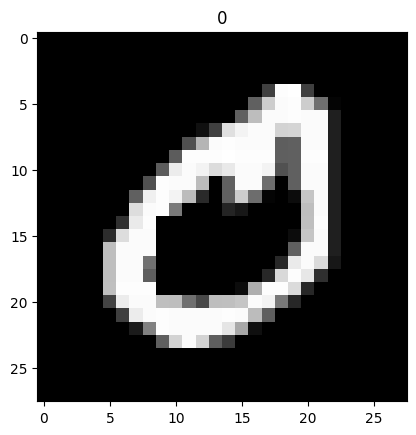

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
plt.imshow(X_train[21], cmap='gray')
plt.title(y_train[21])

In [3]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

In [4]:
X_test[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [5]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [6]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [7]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [8]:
def treina_dl(n_camadas_ocultas, n_units, activation, drop_out, epochs):
    # 1. CONFIGURAÇÃO DO MLFLOW (Resolve o erro de pasta corrompida)
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("DLExperimento")

    with mlflow.start_run():
        # Autolog registra métricas e parâmetros automaticamente
        mlflow.tensorflow.autolog()

        modelo = Sequential()

        # 2. CORREÇÃO DO KERAS (Jeito moderno de definir entrada)
        # Substitui o input_dim=784 da camada Dense
        modelo.add(Input(shape=(784,)))

        # Primeira camada oculta
        modelo.add(Dense(units=n_units, activation=activation))
        modelo.add(Dropout(drop_out))

        # Camadas ocultas adicionais (Loop)
        for n in range(n_camadas_ocultas):
            modelo.add(Dense(units=n_units, activation=activation))
            modelo.add(Dropout(drop_out))

        # Camada de saída
        modelo.add(Dense(units=10, activation='softmax'))

        modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        modelo.summary()

        # Treinamento
        historico = modelo.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test))

        # 3. GRÁFICOS PERSONALIZADOS
        # Limpamos a figura antes de plotar para não sobrepor gráficos
        plt.figure()
        plt.plot(historico.history['val_loss'], label='Erro (Loss)')
        plt.title("Evolução do Erro")
        plt.legend()
        plt.savefig('loss.png')

        plt.figure()
        plt.plot(historico.history['val_accuracy'], label='Acurácia')
        plt.title("Evolução da Acurácia")
        plt.legend()
        plt.savefig("acuracia.png")

        # Registrar os gráficos manualmente (já que o autolog foca nas métricas numéricas)
        mlflow.log_artifact('loss.png')
        mlflow.log_artifact('acuracia.png')

        print(f"Modelo treinado! ID da Run: {mlflow.active_run().info.run_id}")

2025/12/21 11:30:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/21 11:30:14 INFO mlflow.store.db.utils: Updating database tables
2025-12-21 11:30:14 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-21 11:30:14 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-12-21 11:30:14 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-21 11:30:14 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
E0000 00:00:1766327414.403717   36951 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1766327414.412903   36951 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9388 - loss: 0.2192 - val_accuracy: 0.9593 - val_loss: 0.1519
Epoch 5/5
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9409 - loss: 0.2067

2025-12-21 12:43:28 WARNI [absl] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9425 - loss: 0.2042 - val_accuracy: 0.9618 - val_loss: 0.1405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


2025/12/21 12:43:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/21 12:43:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modelo treinado! ID da Run: e9a55944e55f46d58df993c942c1339a


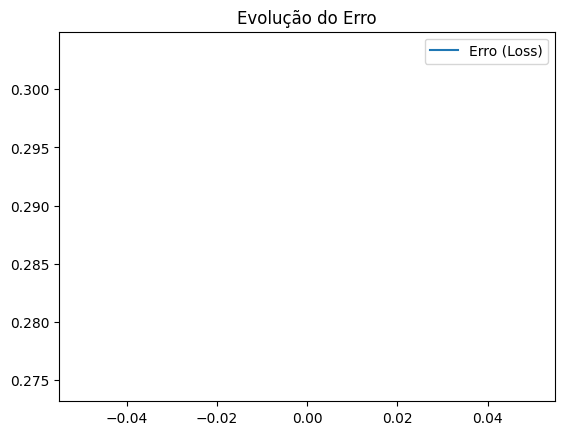

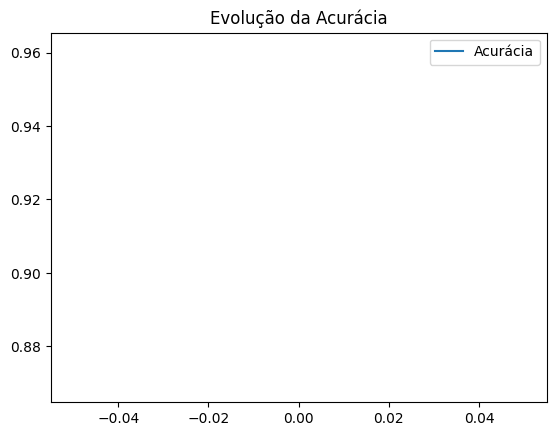

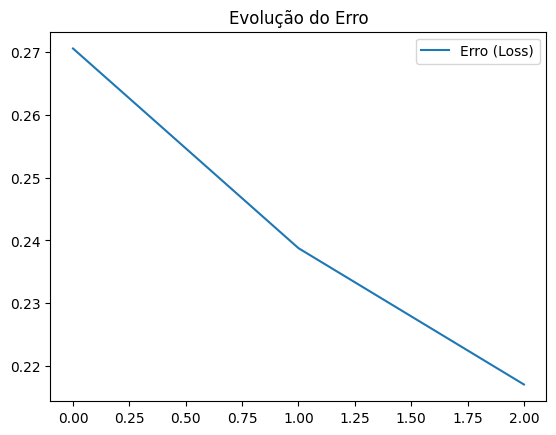

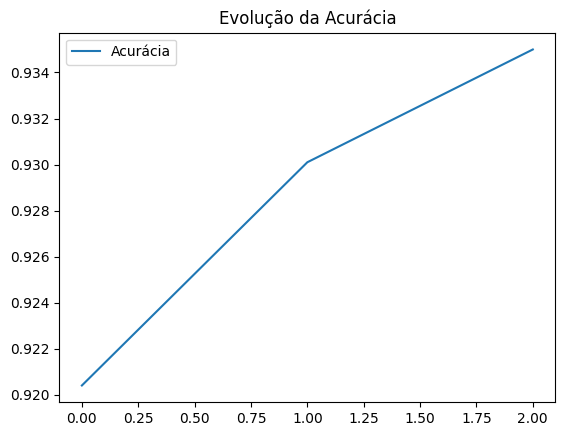

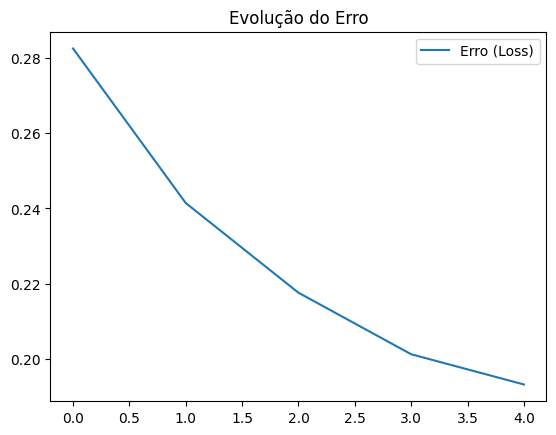

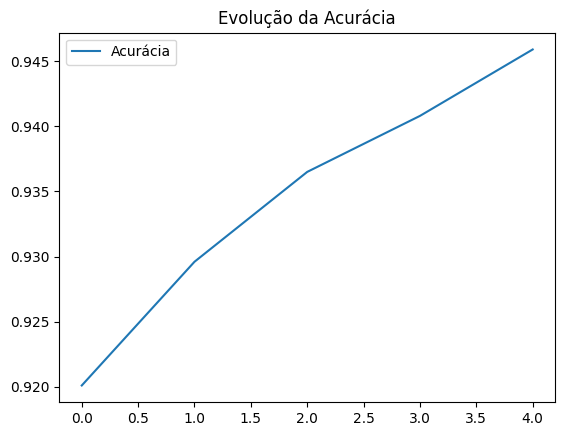

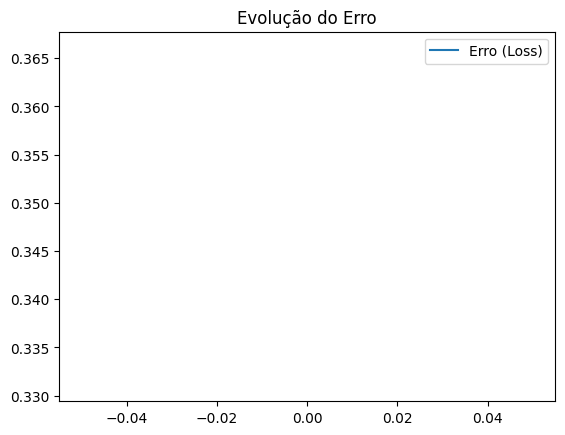

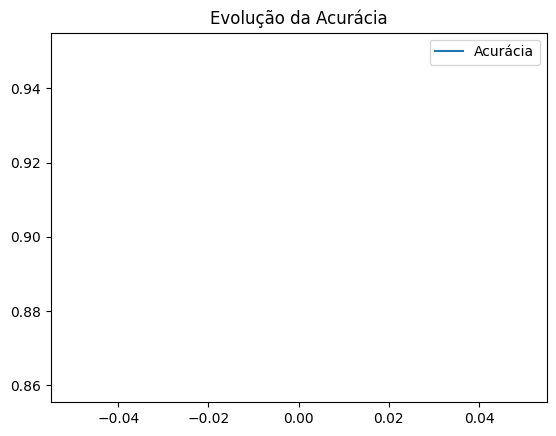

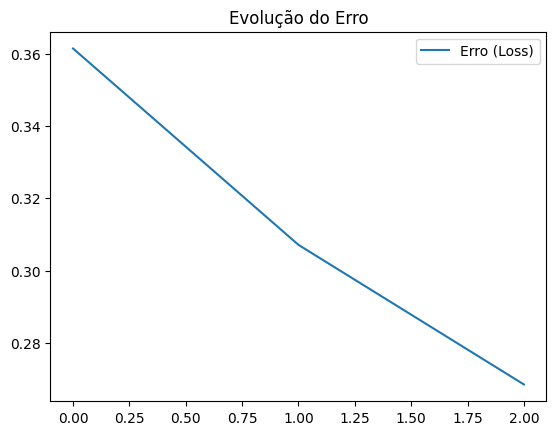

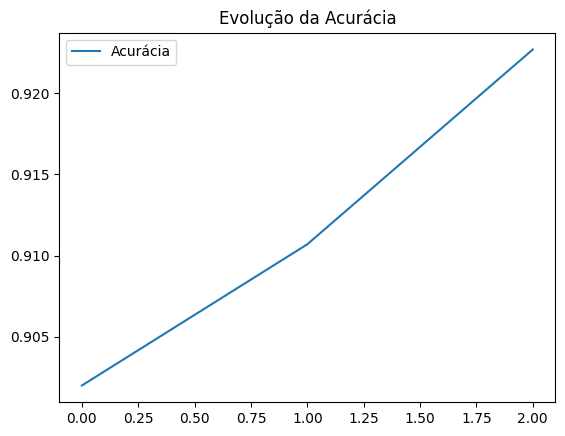

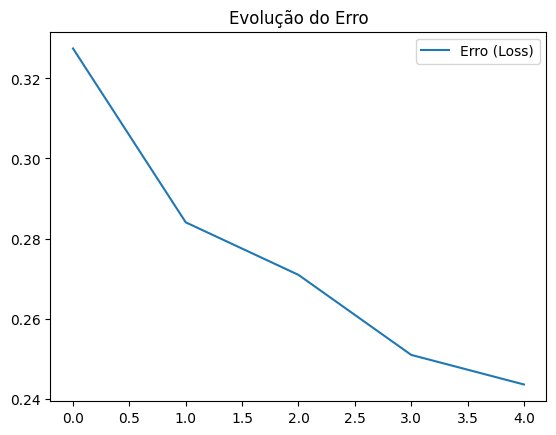

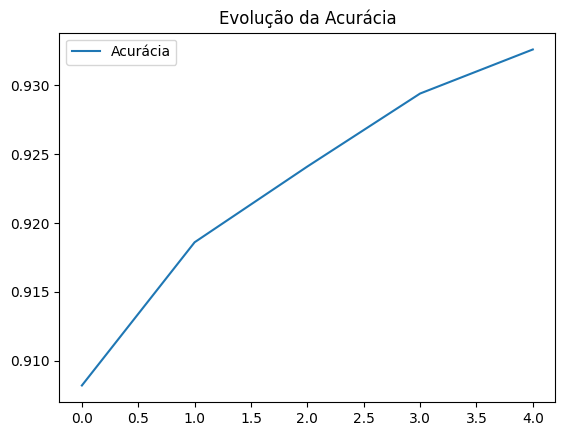

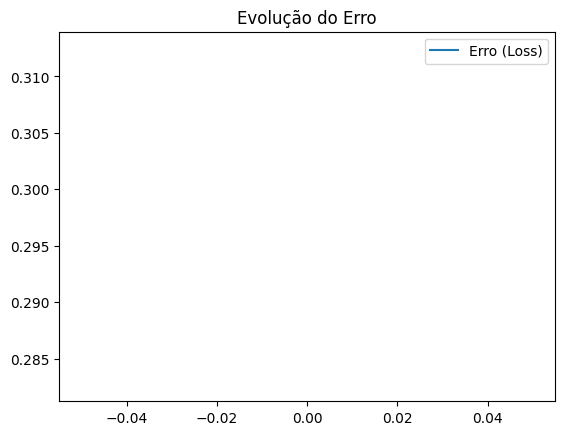

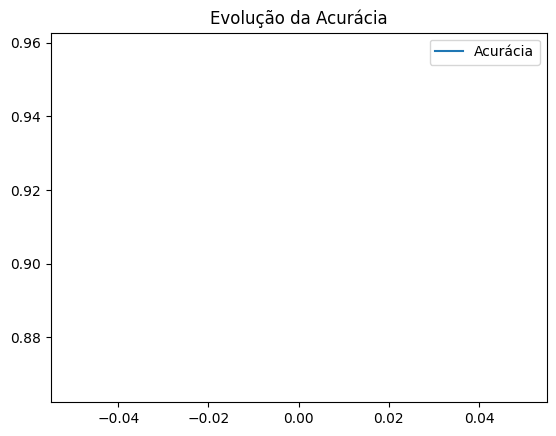

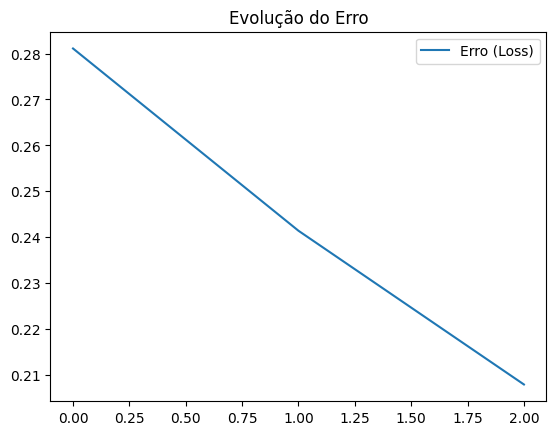

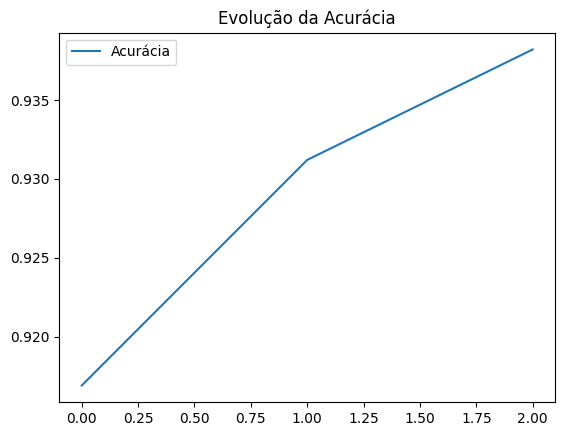

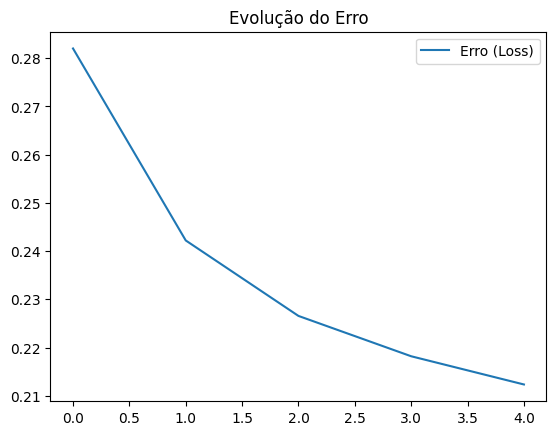

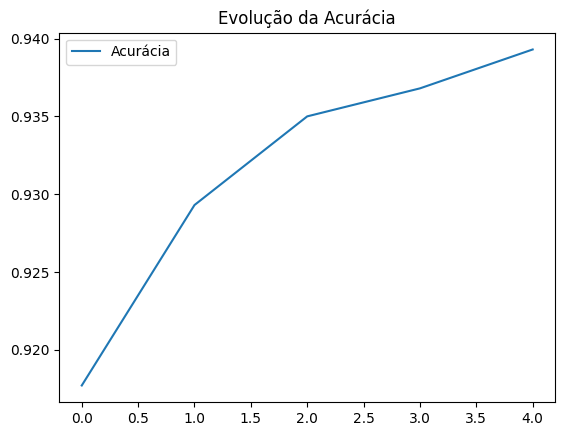

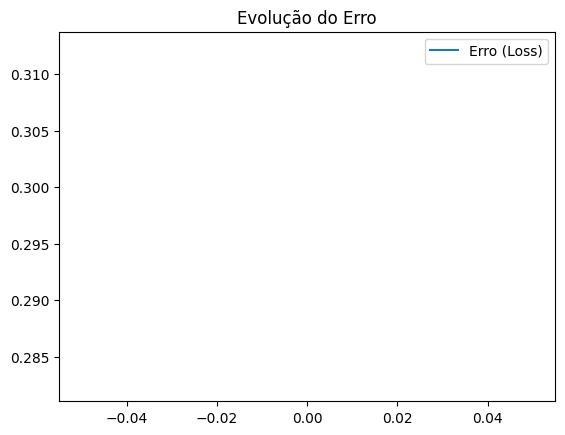

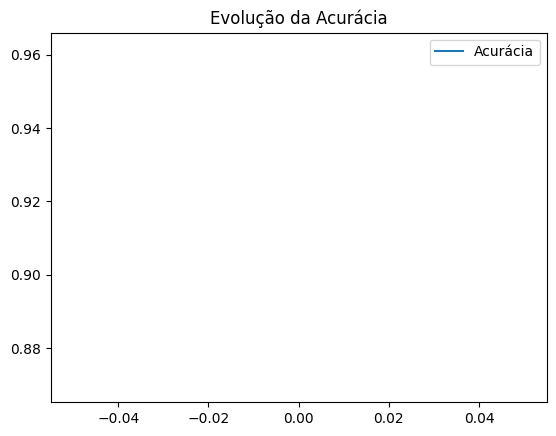

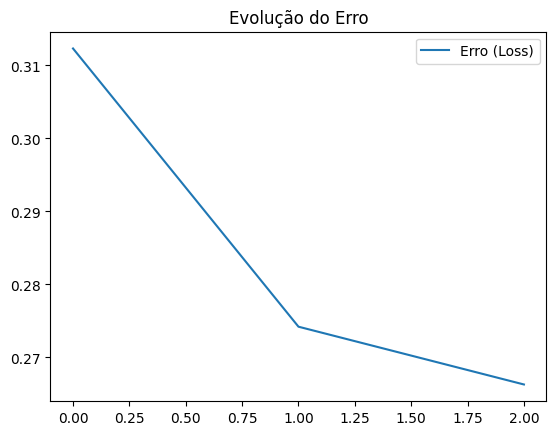

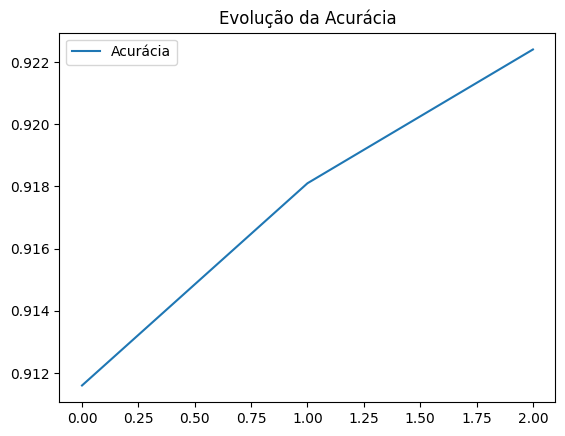

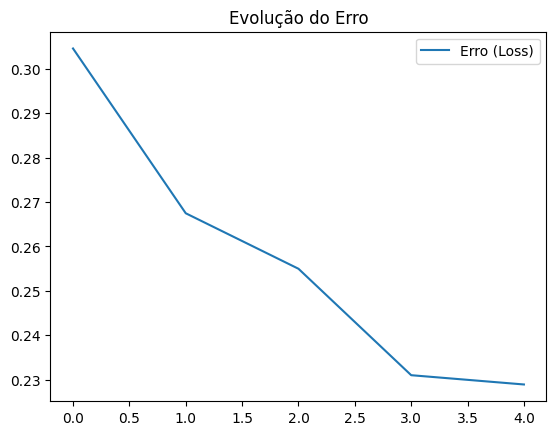

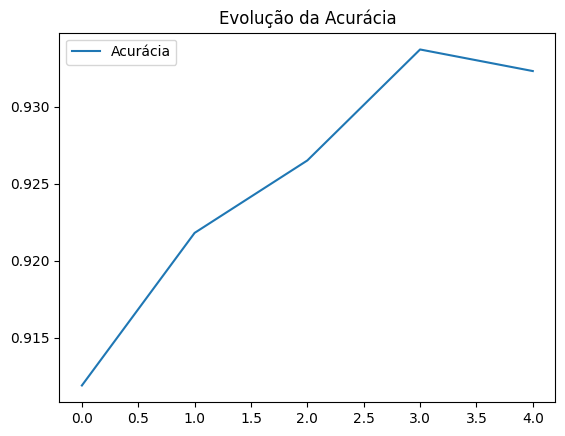

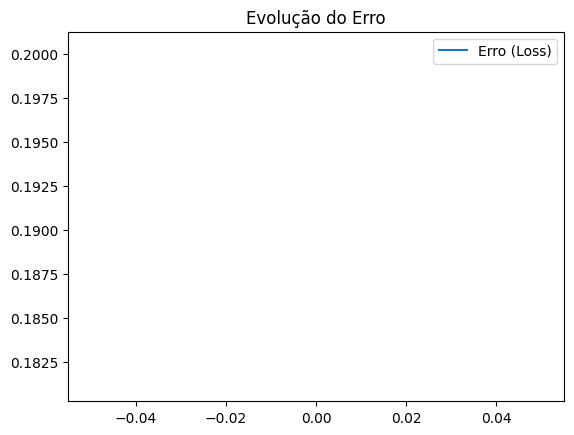

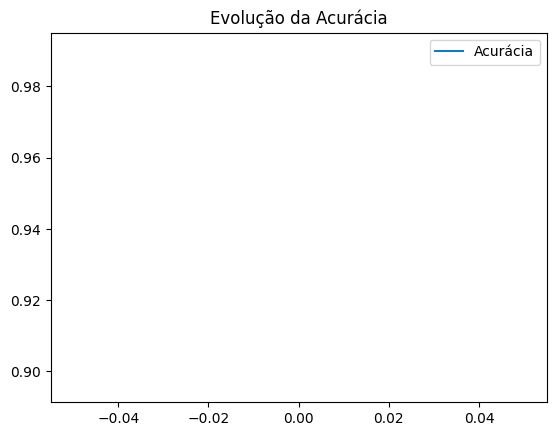

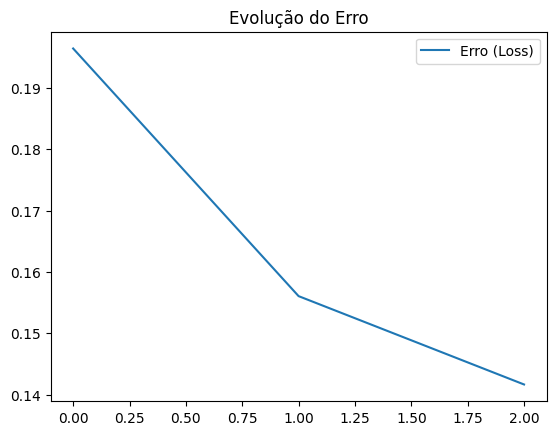

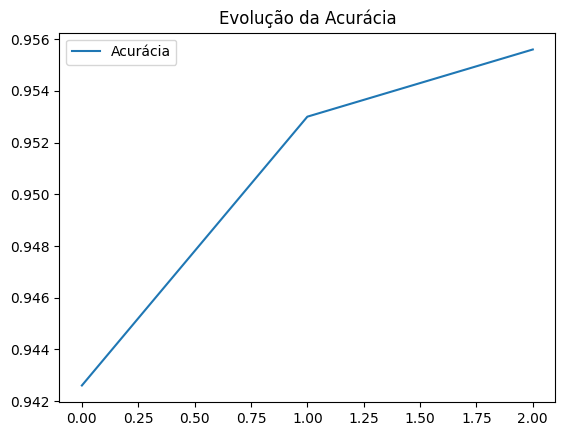

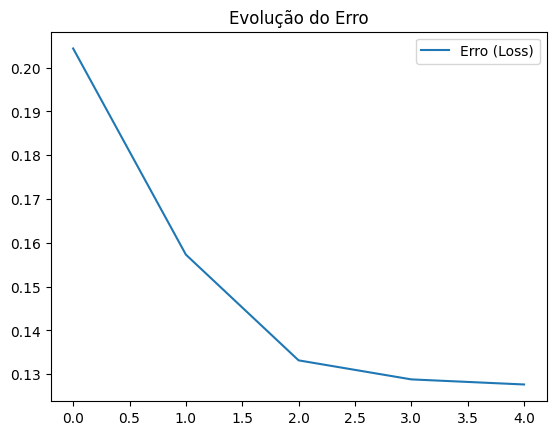

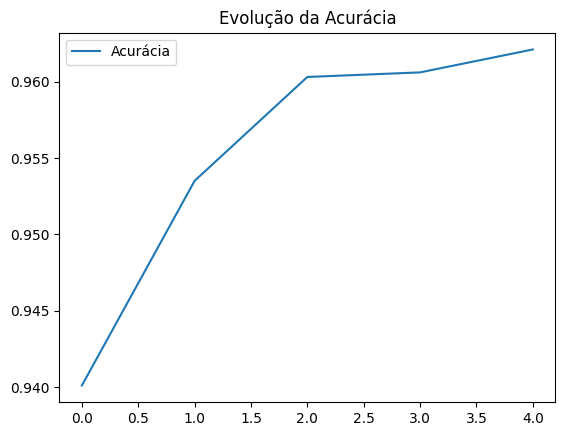

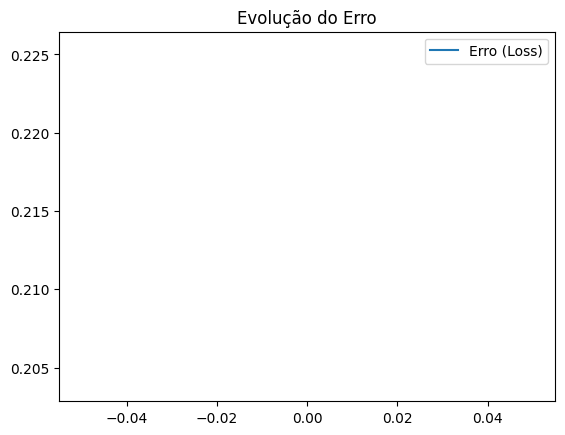

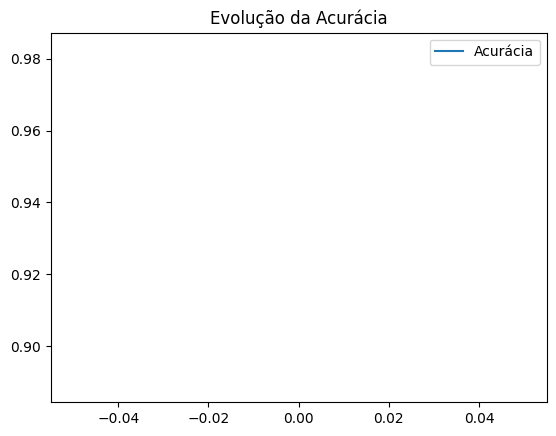

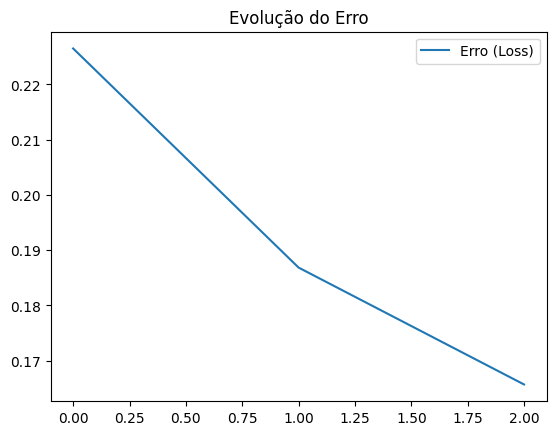

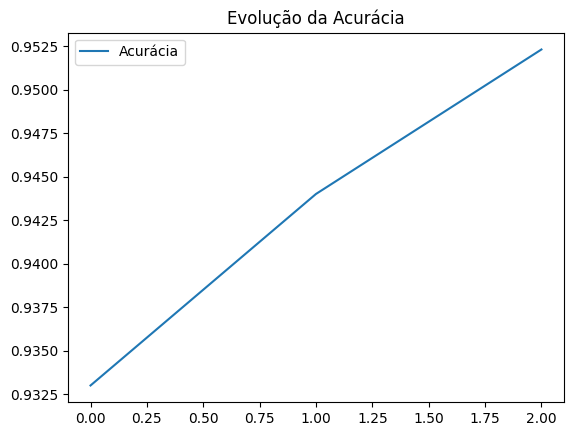

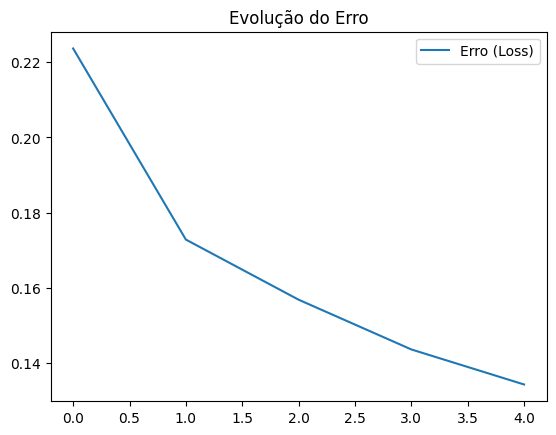

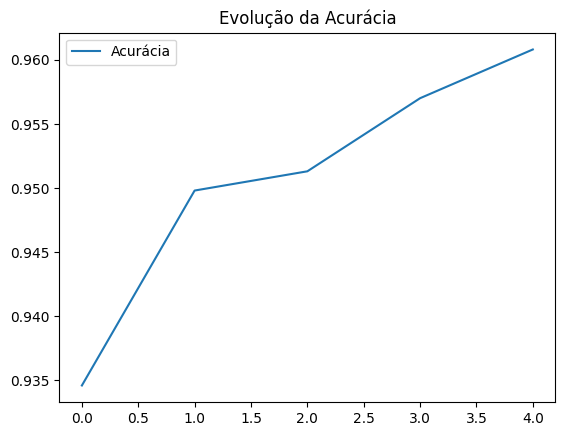

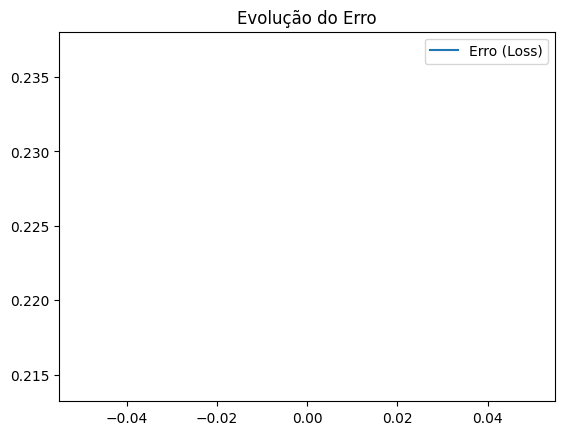

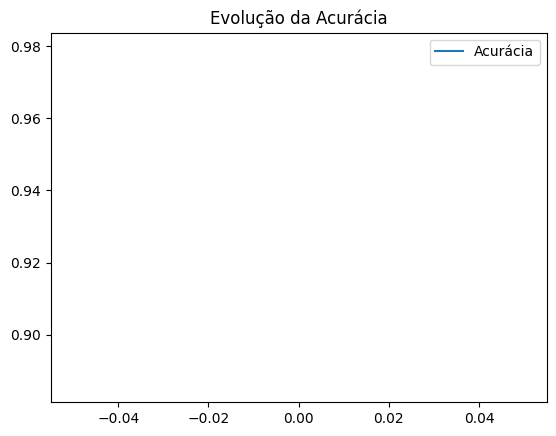

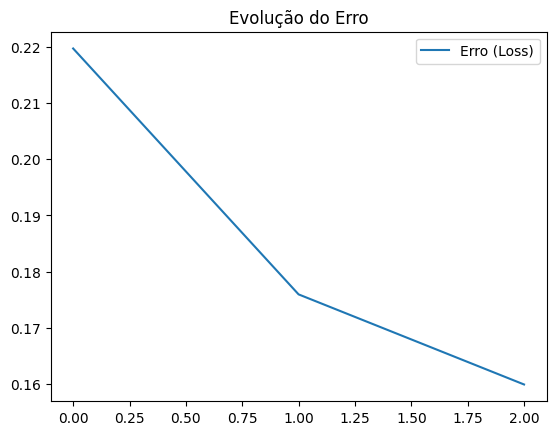

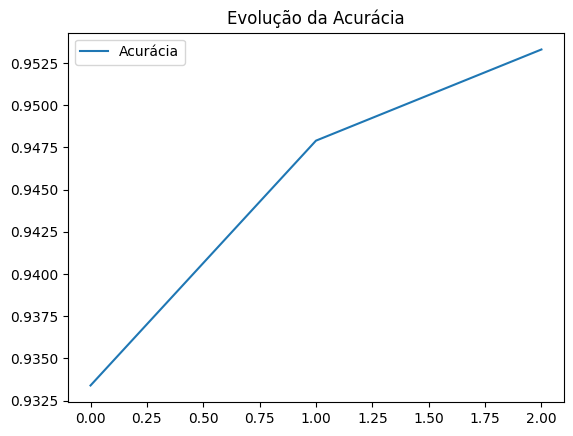

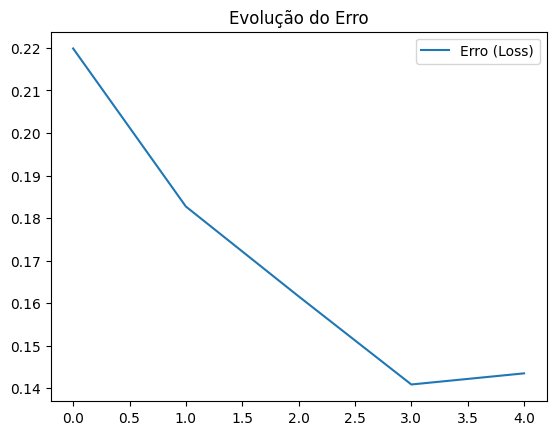

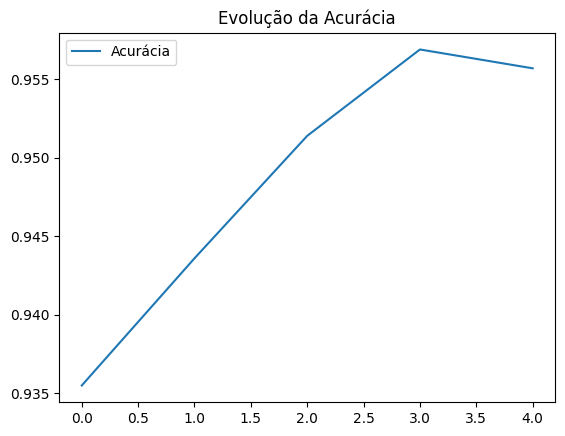

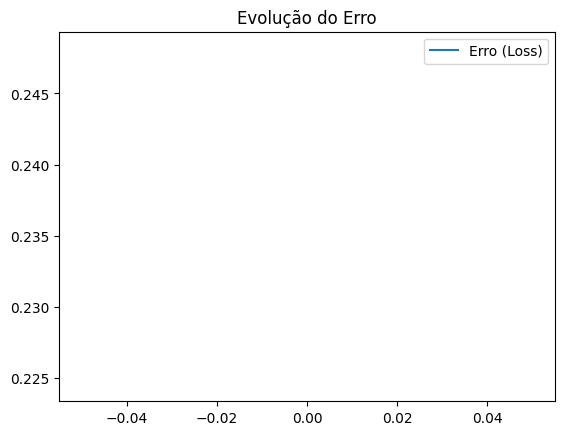

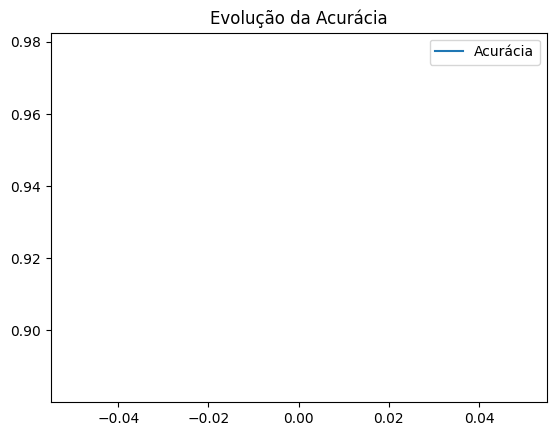

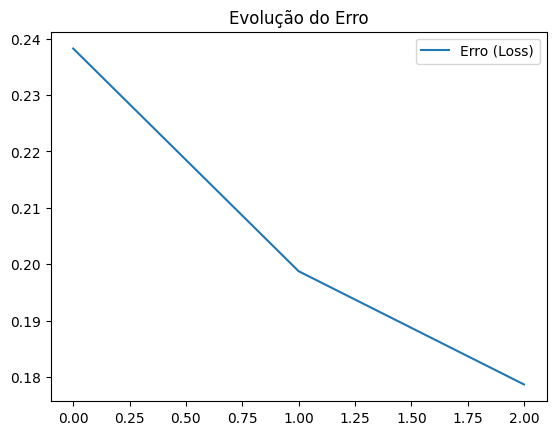

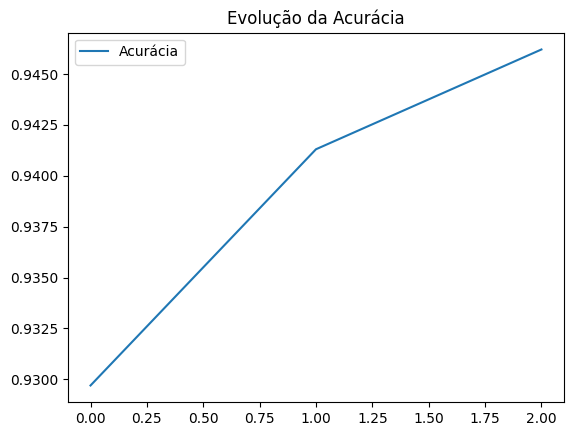

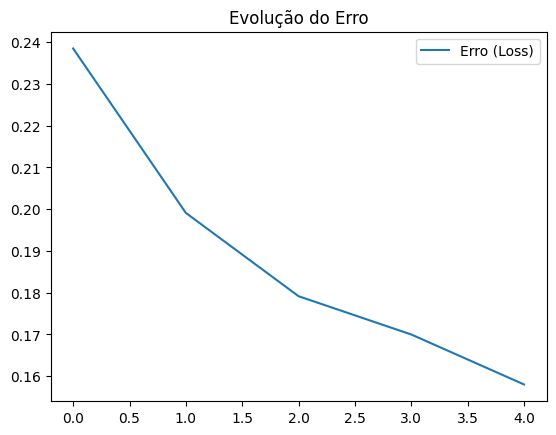

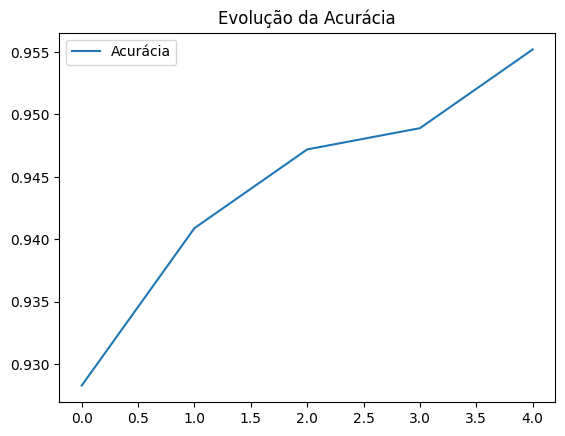

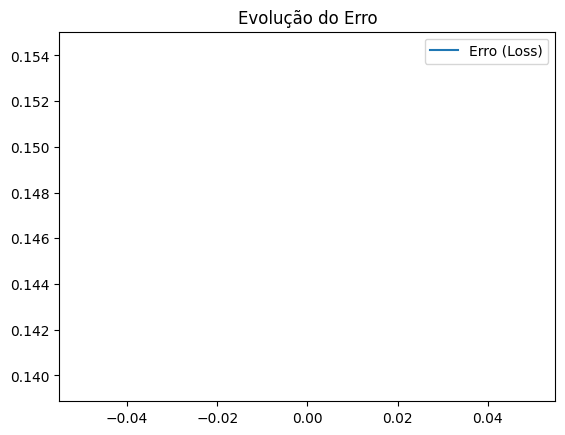

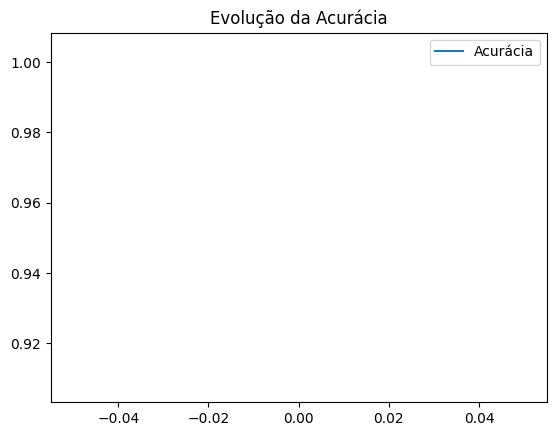

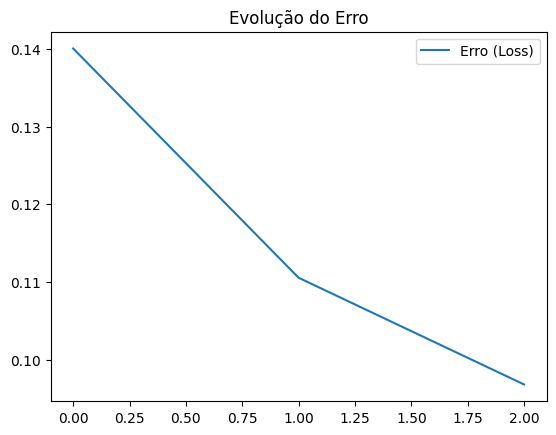

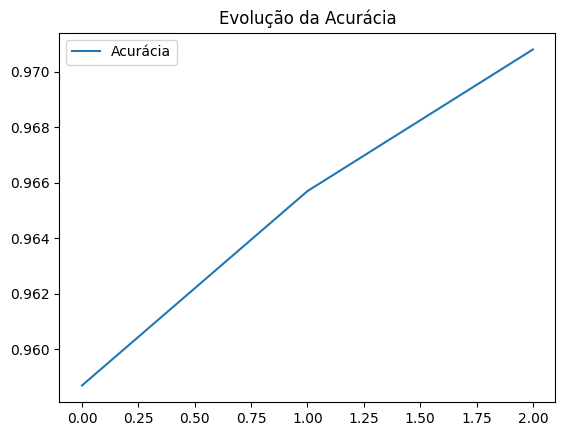

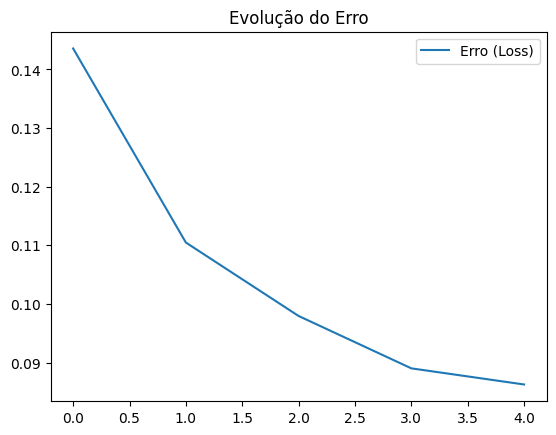

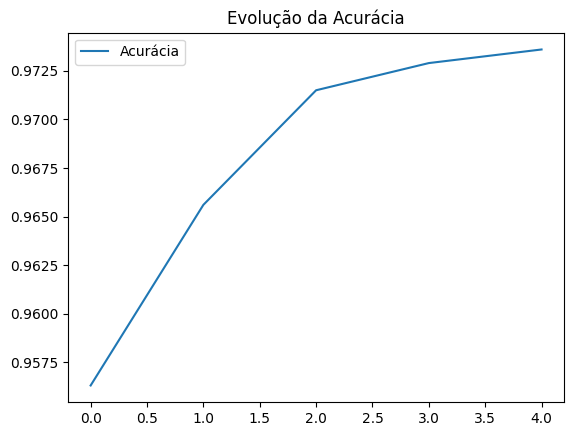

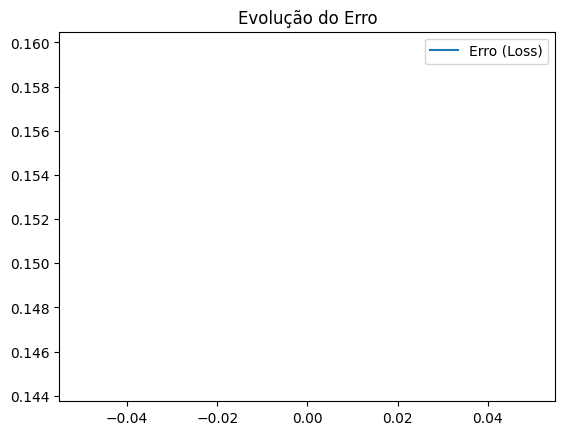

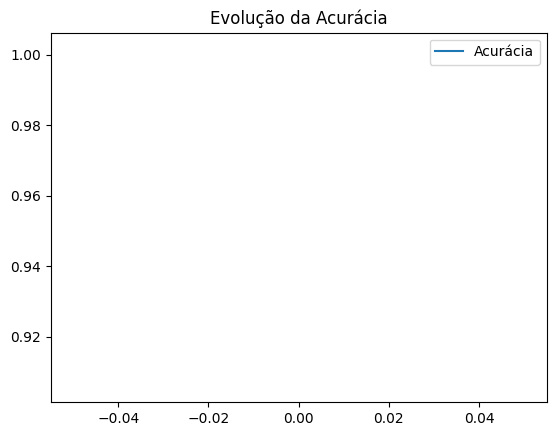

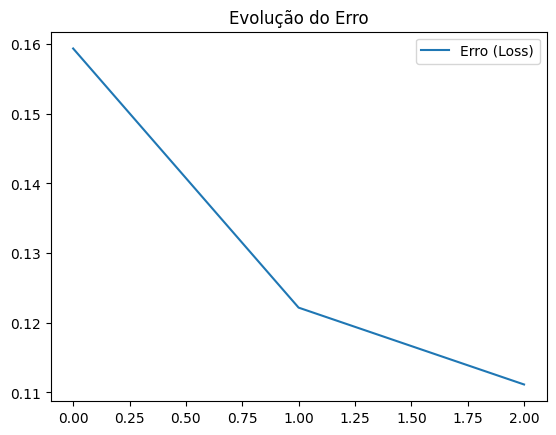

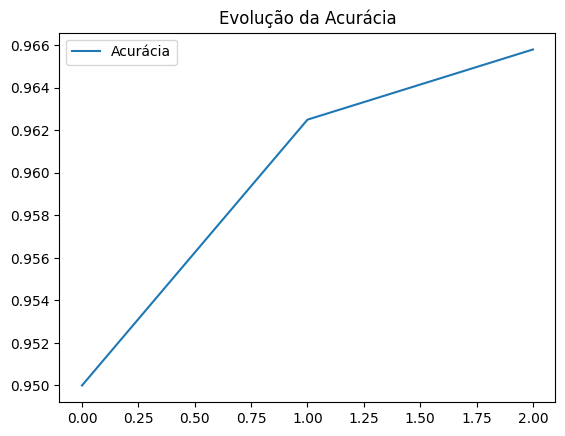

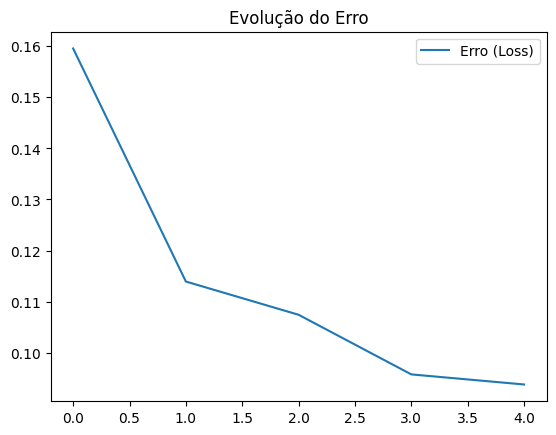

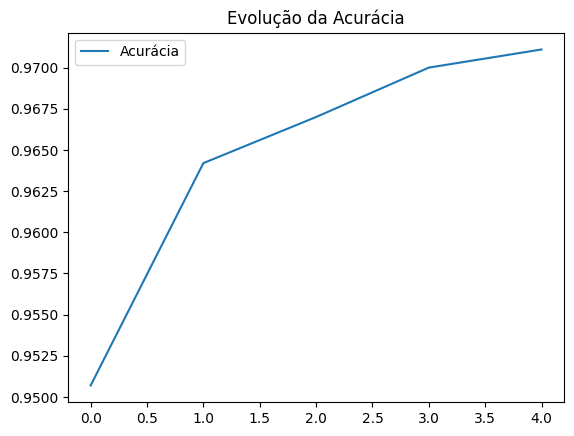

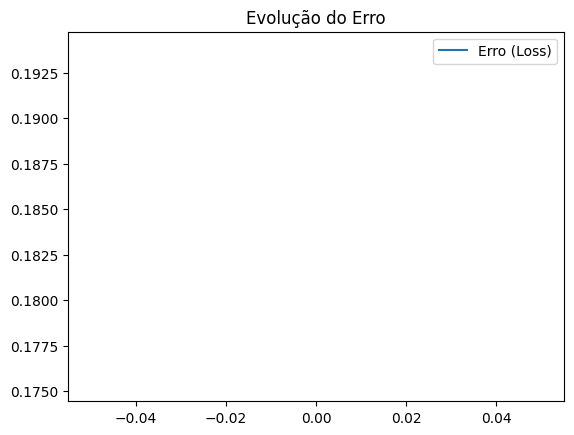

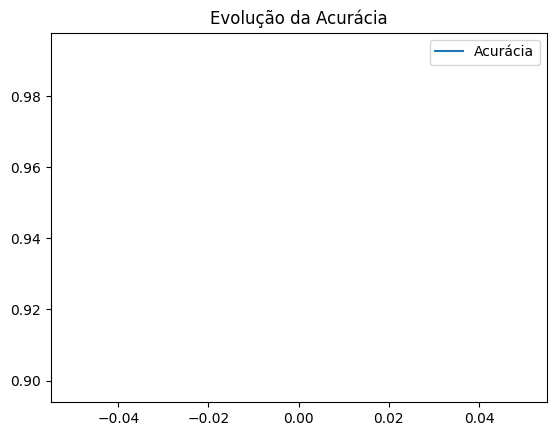

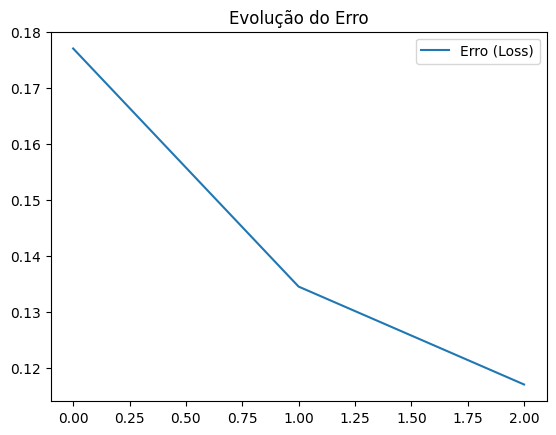

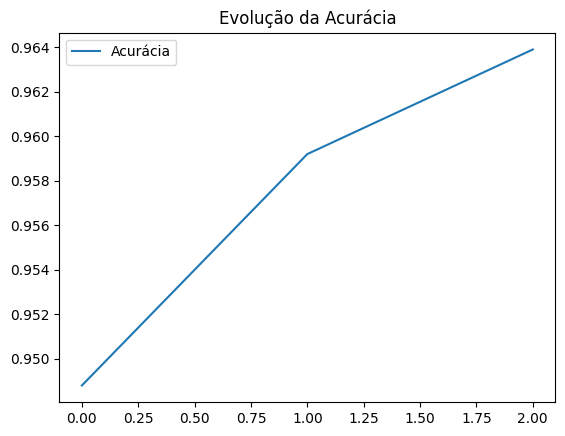

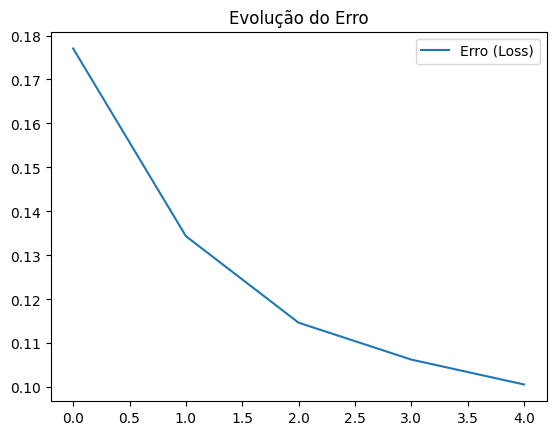

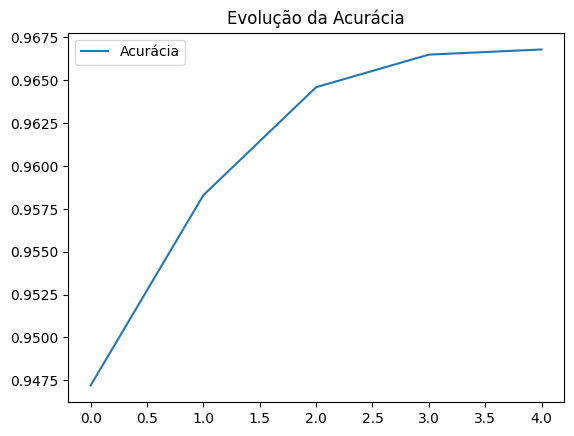

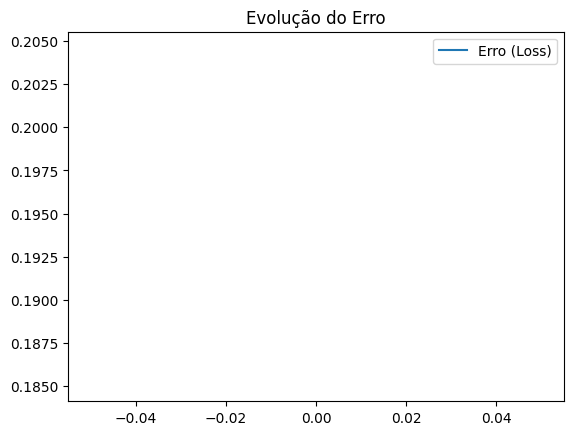

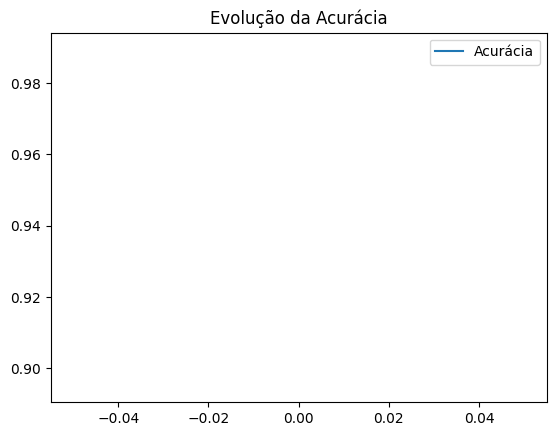

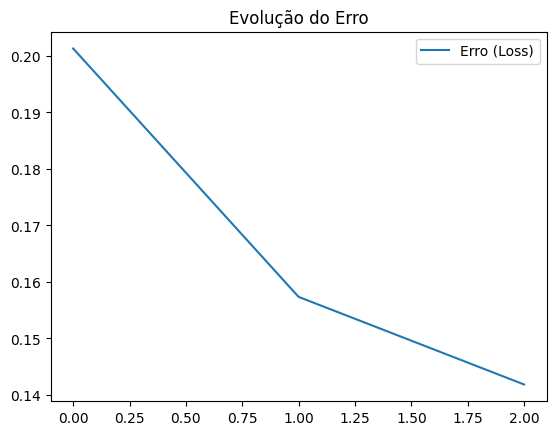

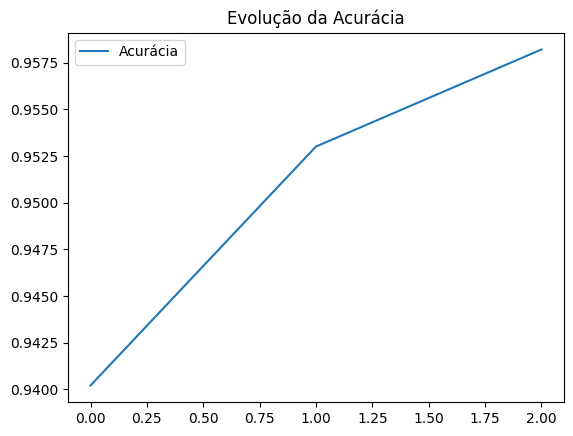

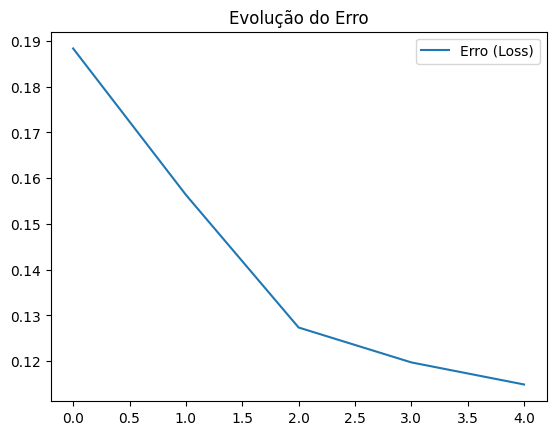

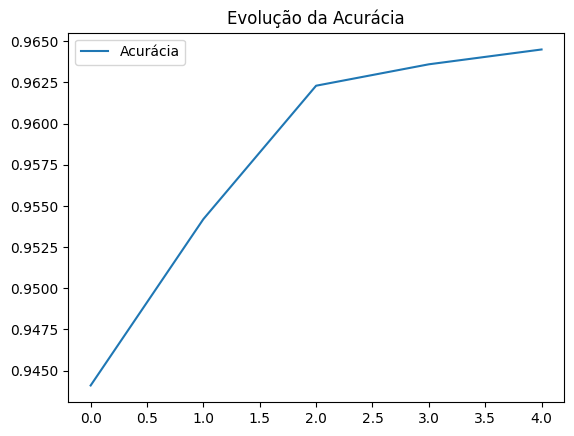

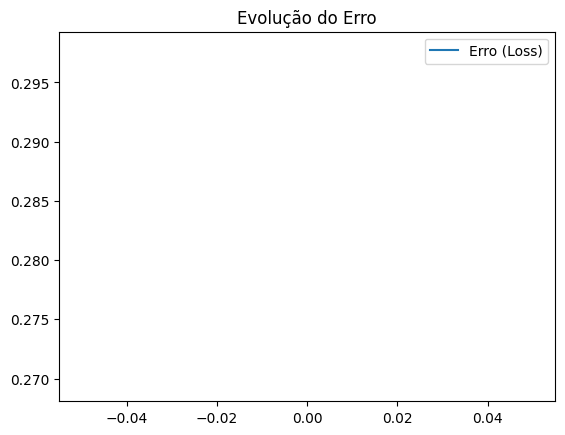

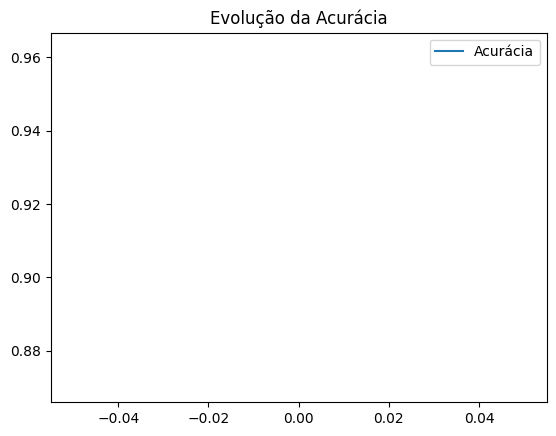

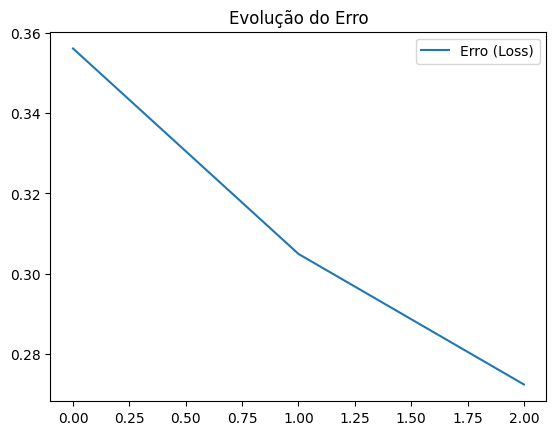

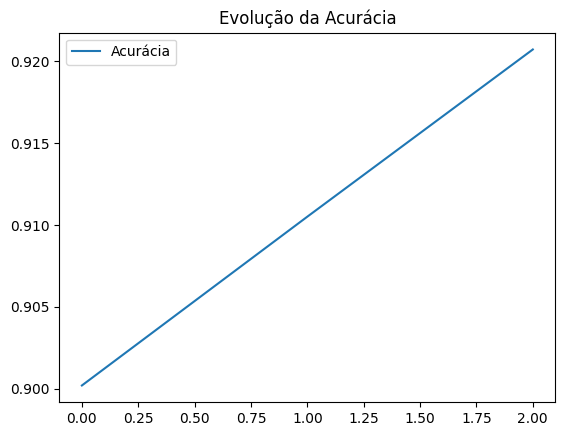

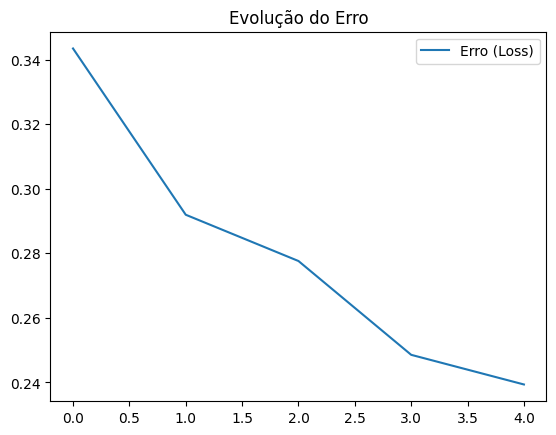

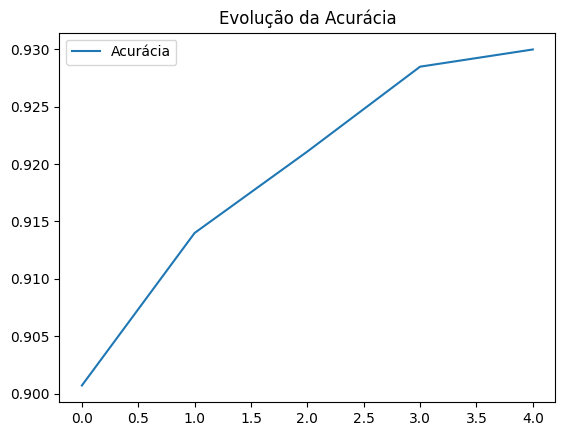

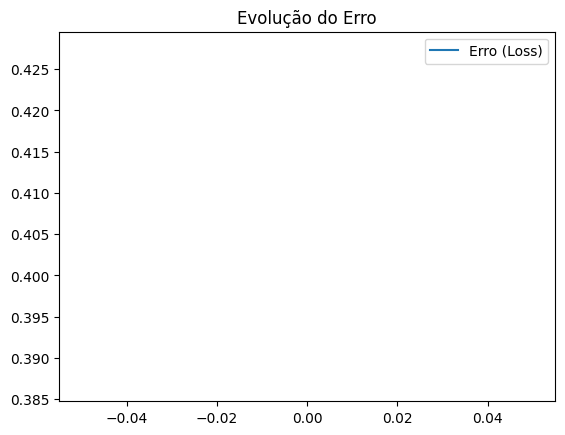

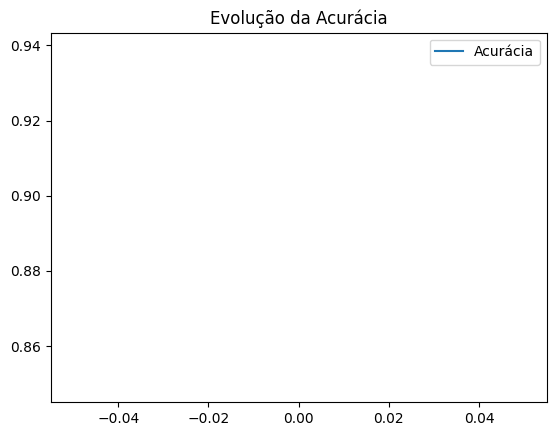

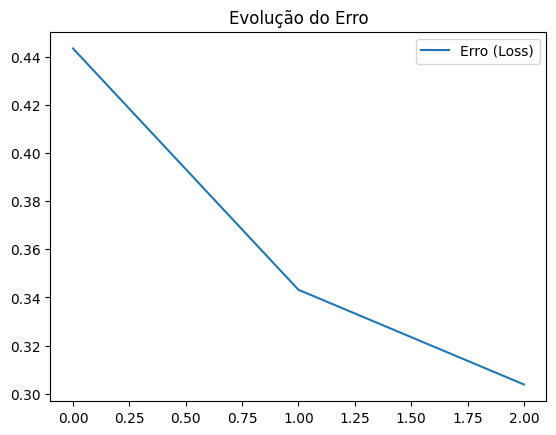

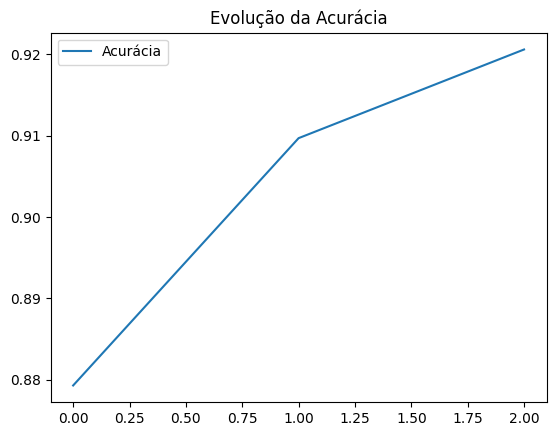

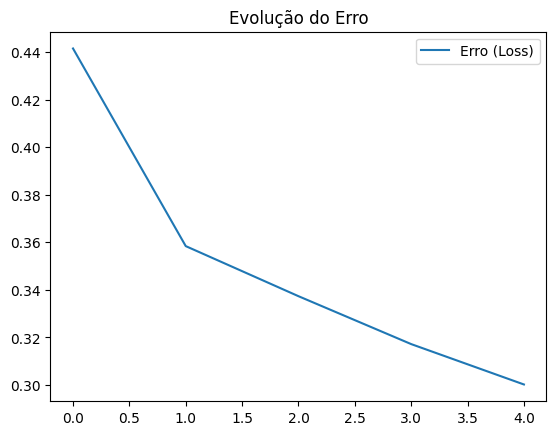

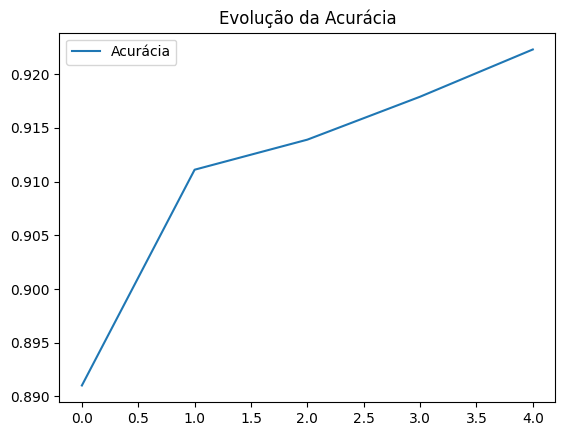

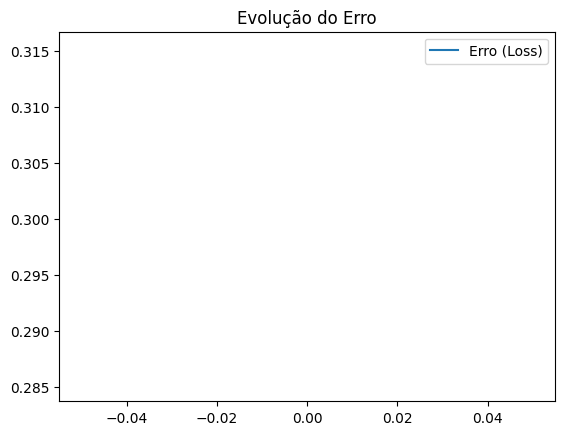

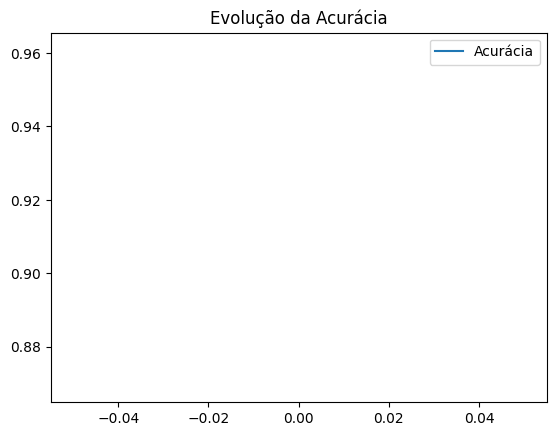

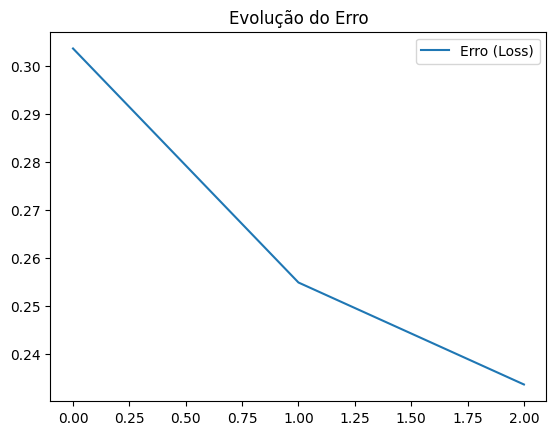

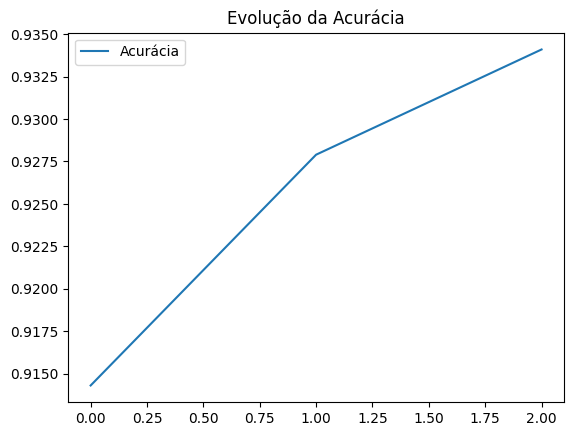

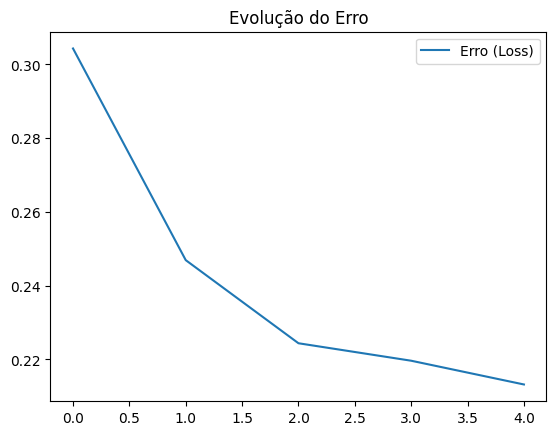

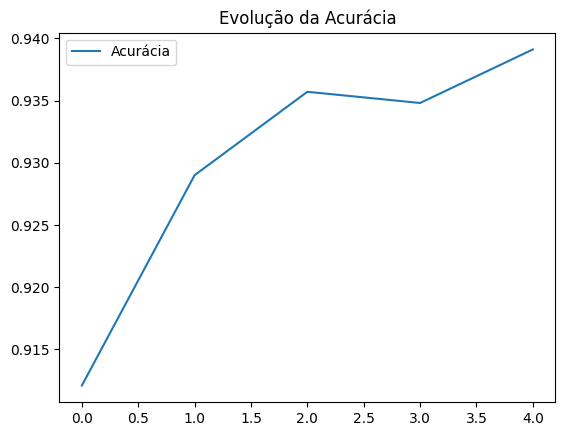

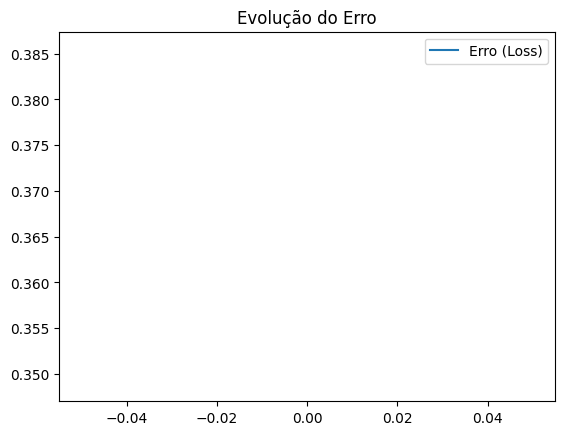

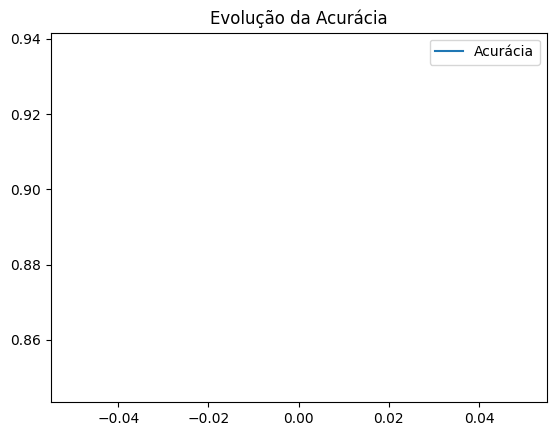

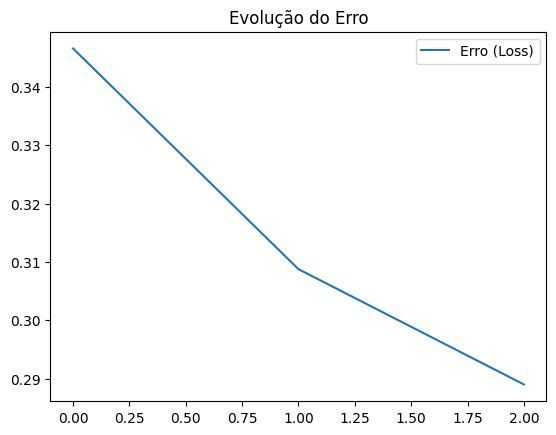

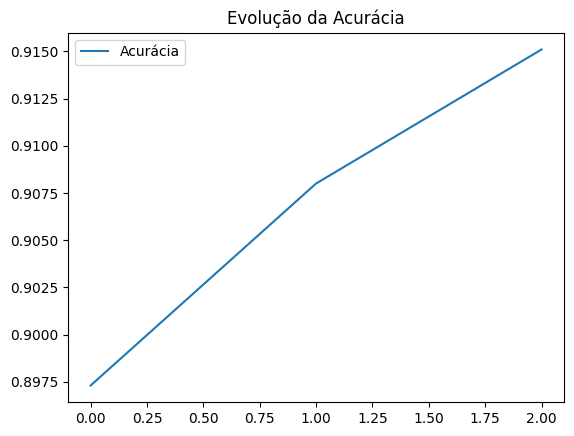

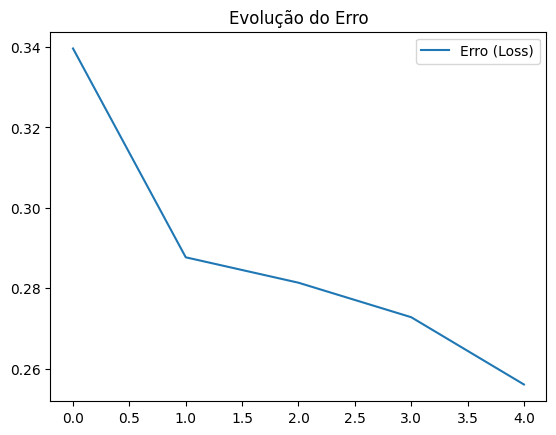

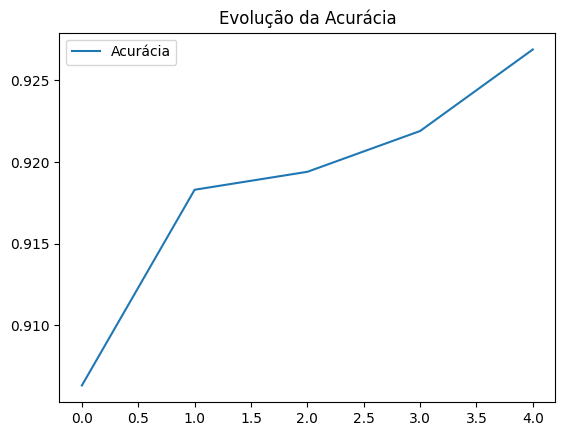

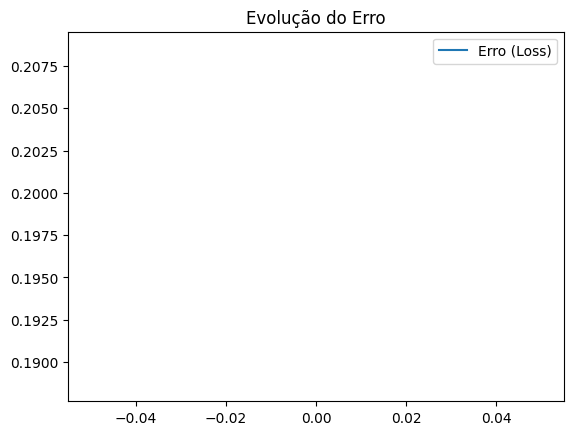

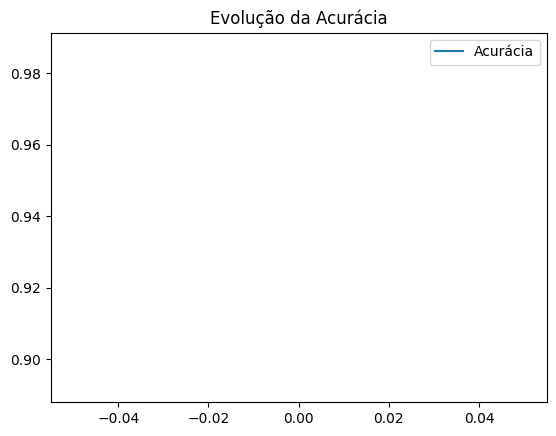

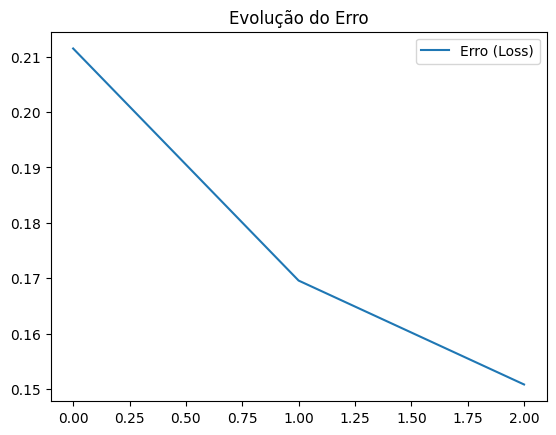

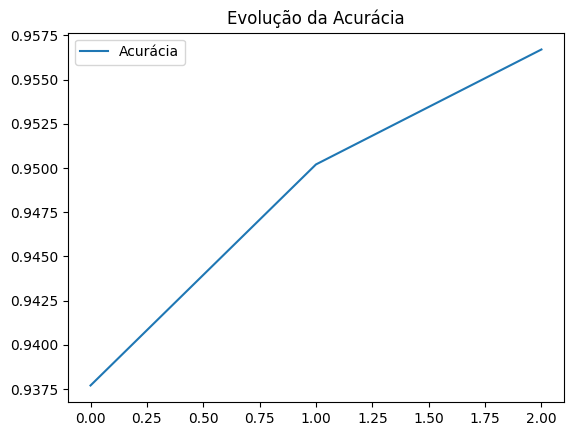

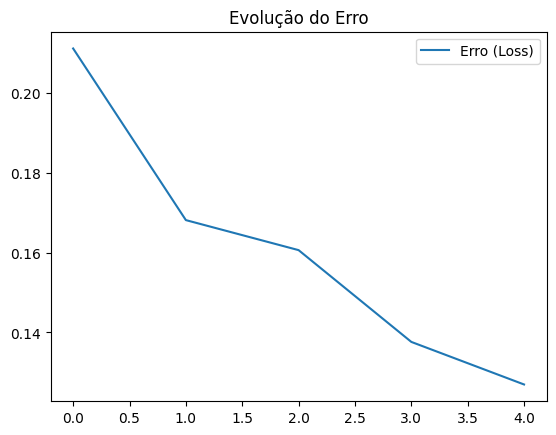

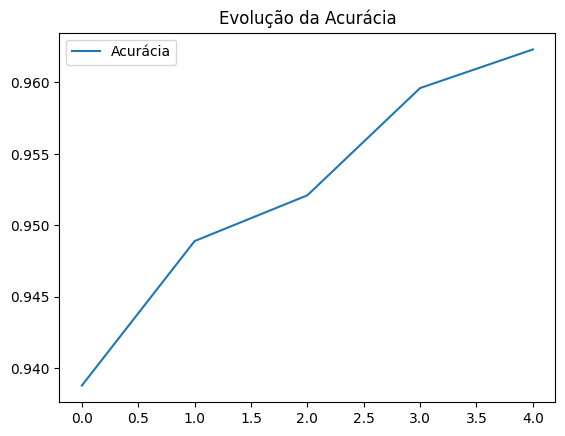

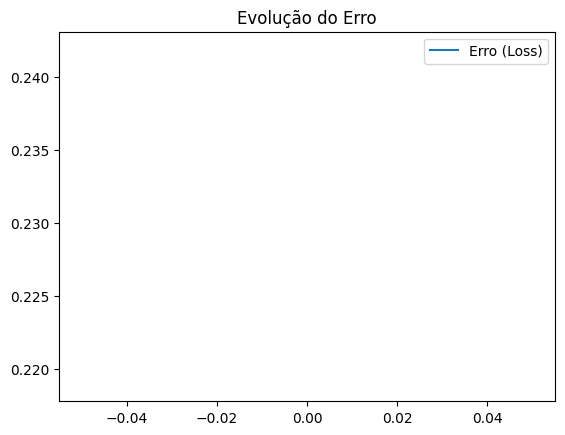

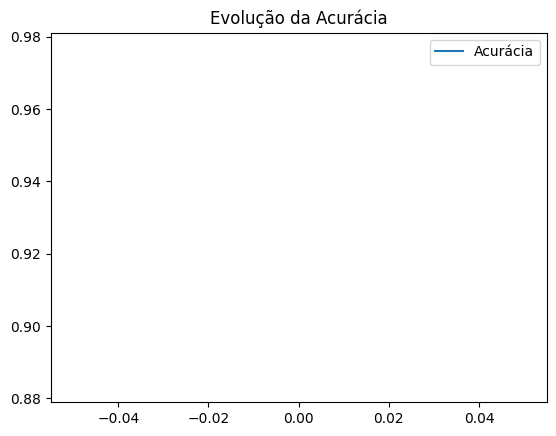

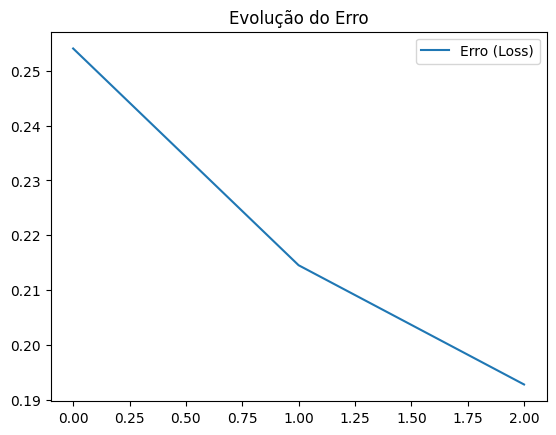

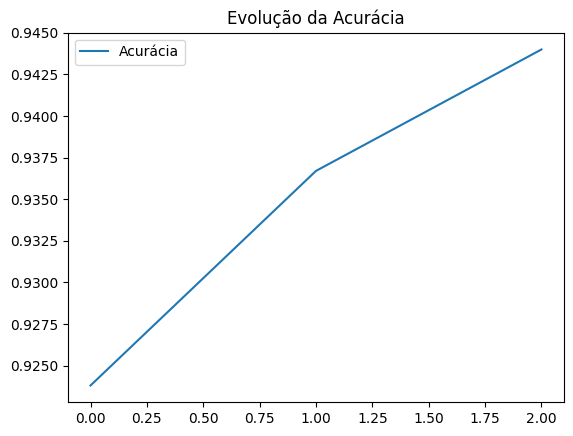

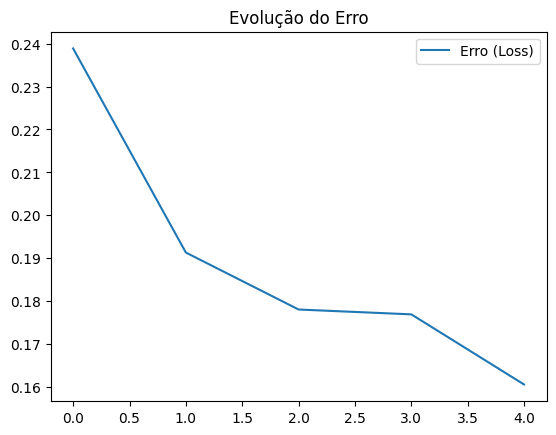

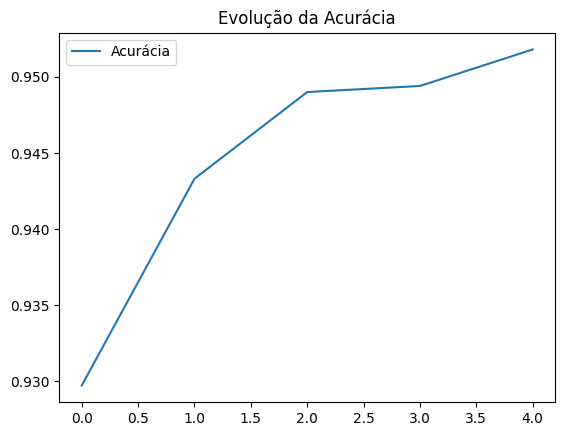

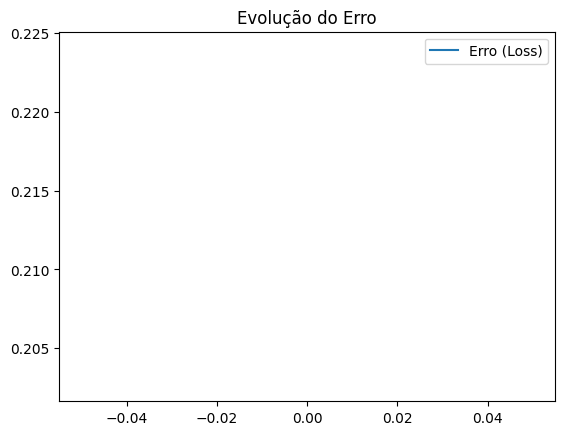

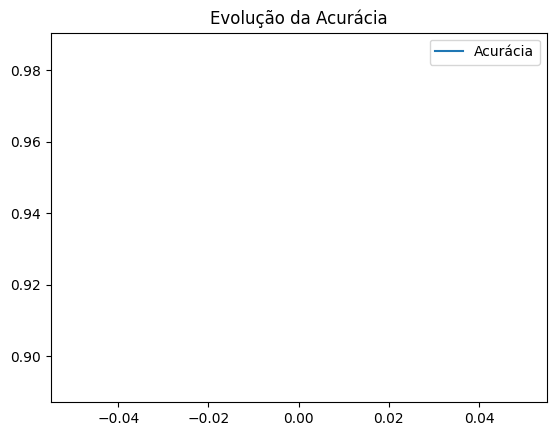

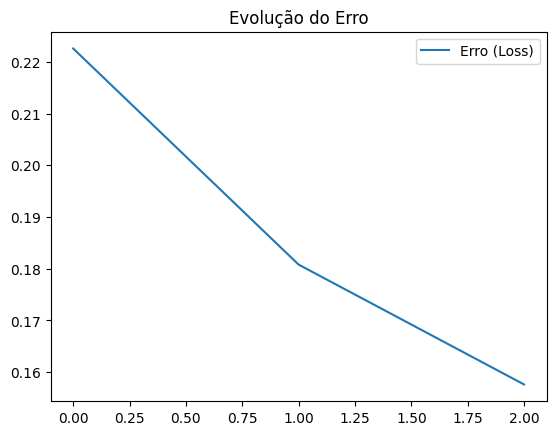

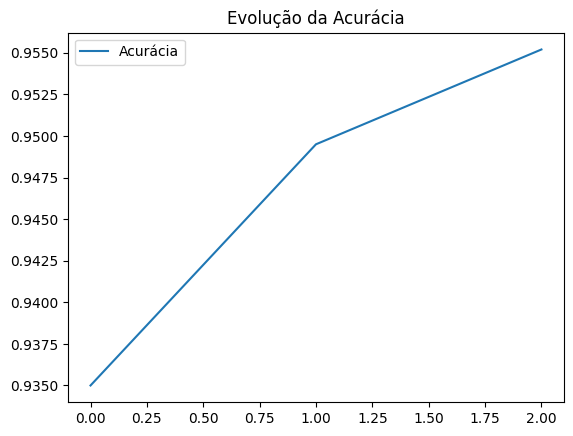

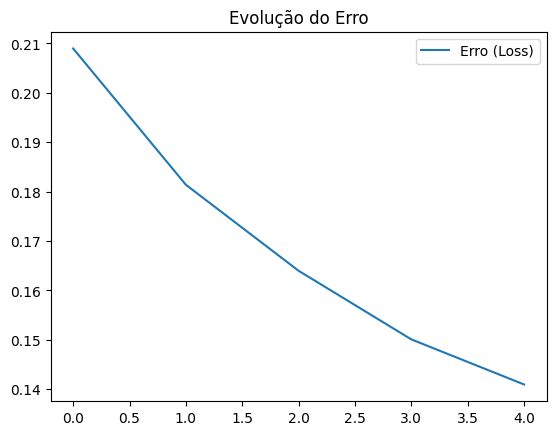

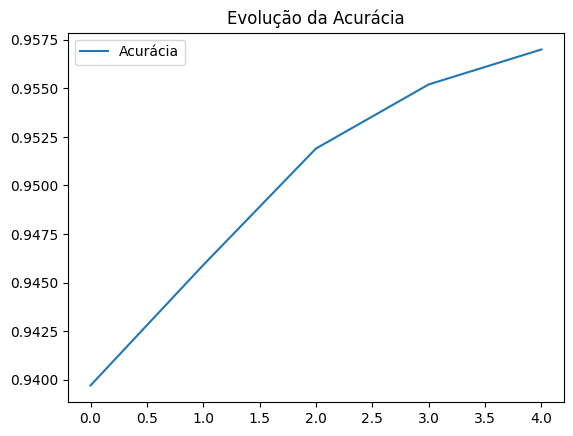

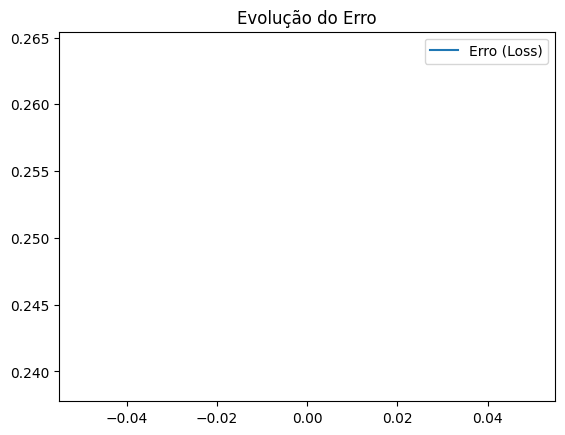

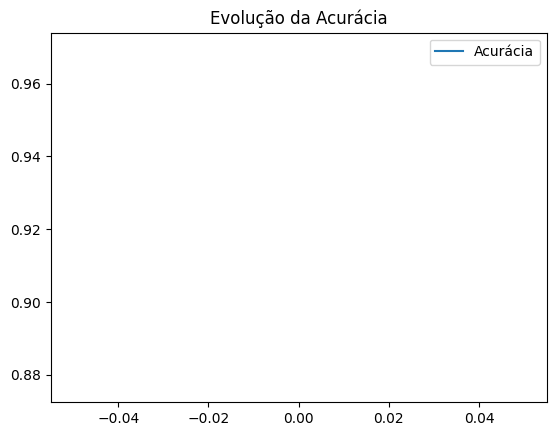

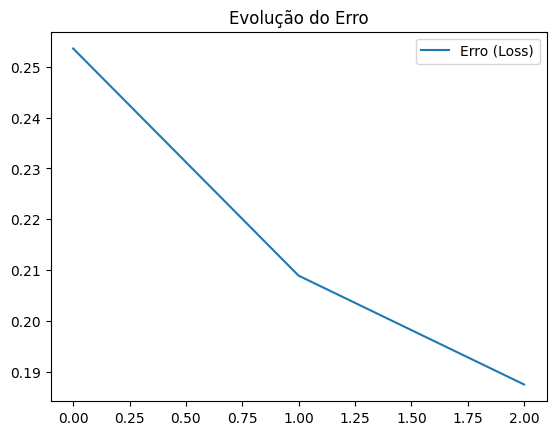

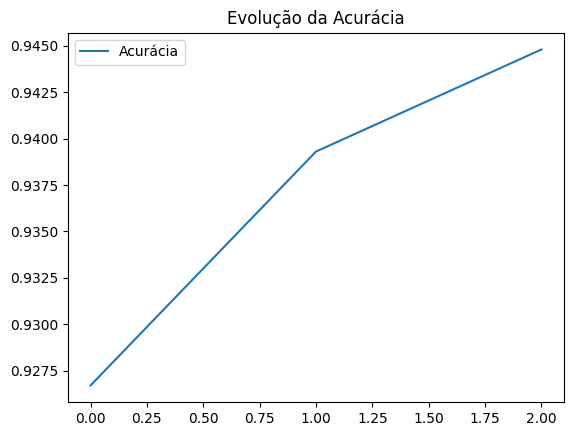

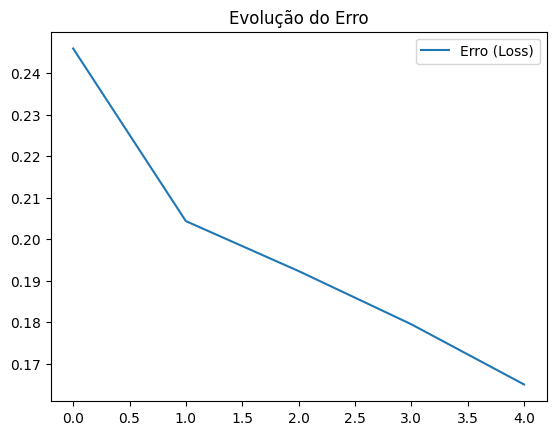

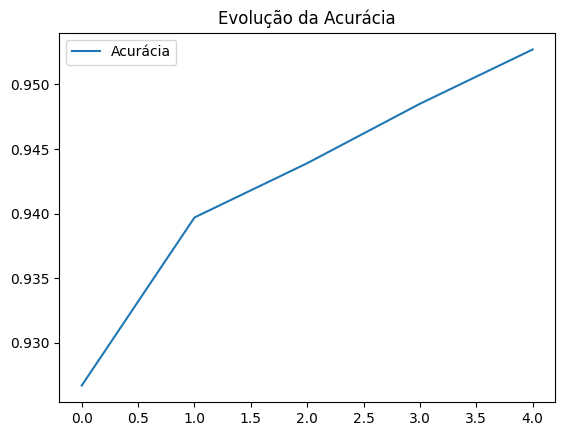

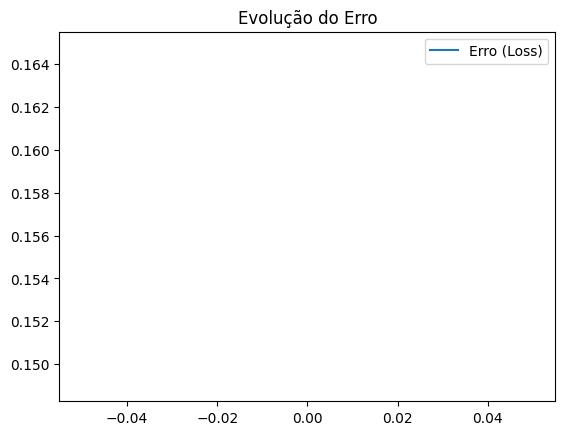

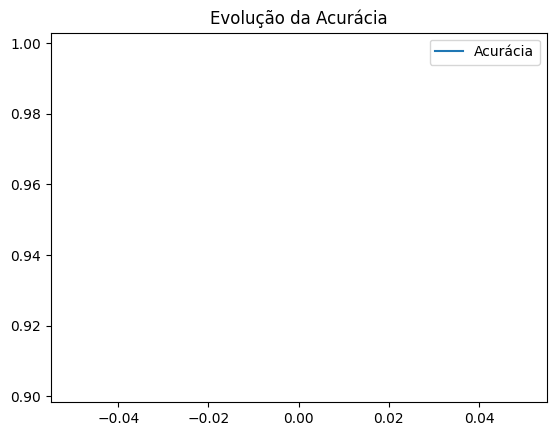

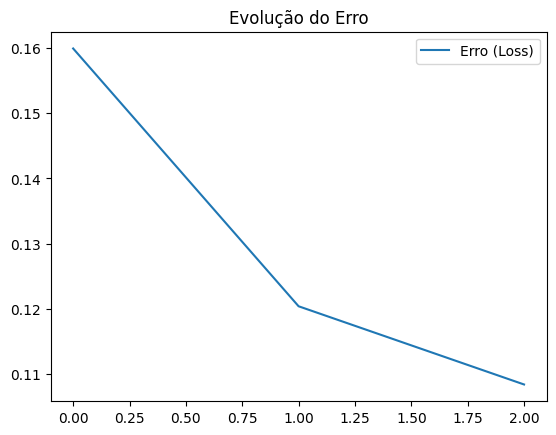

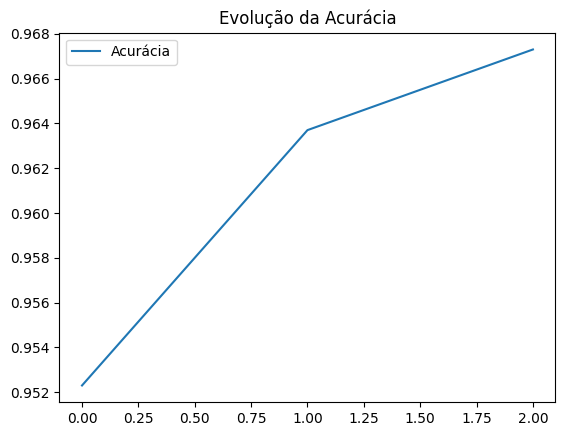

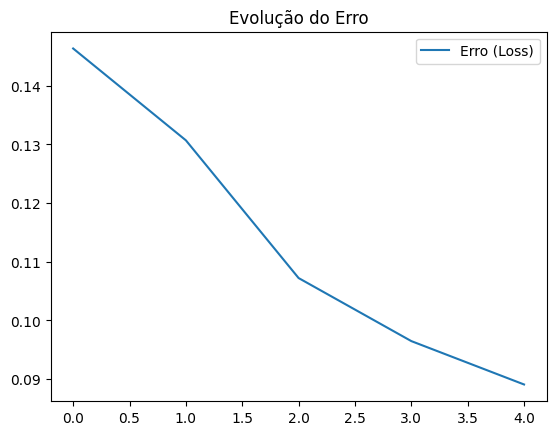

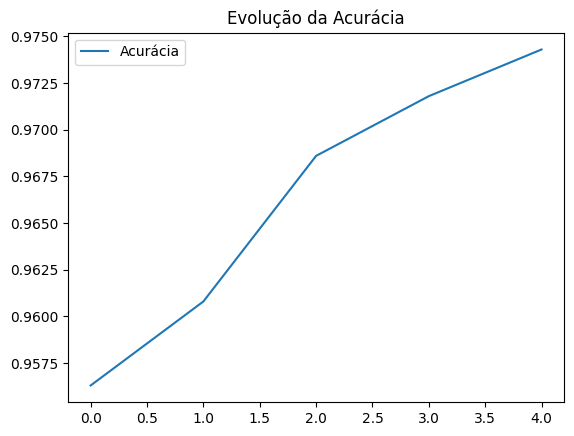

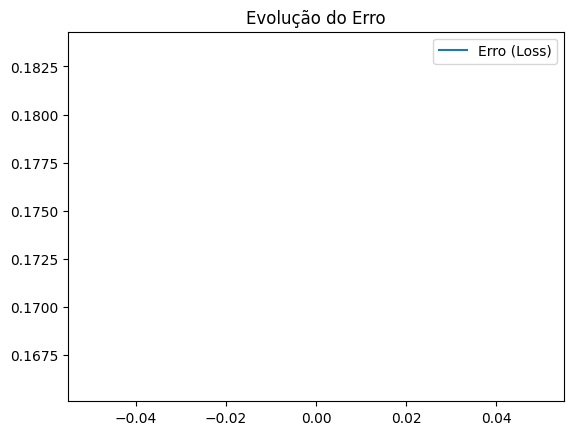

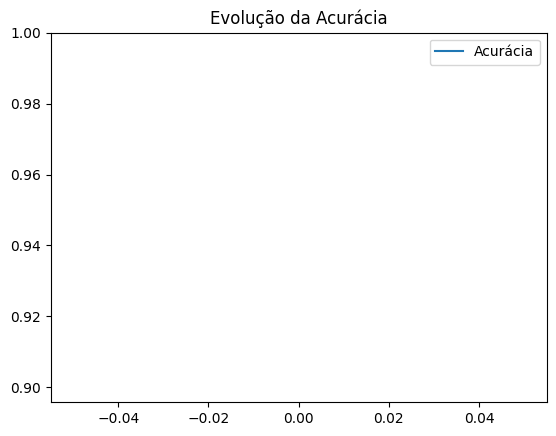

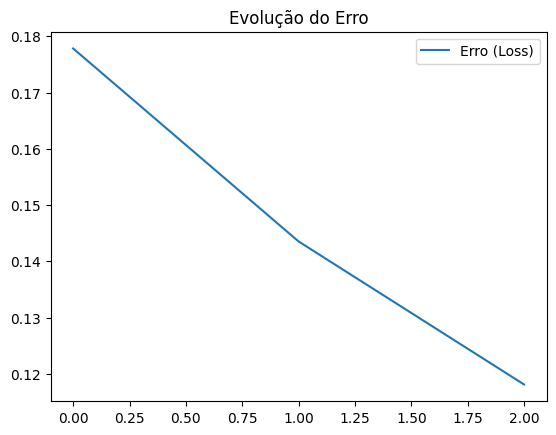

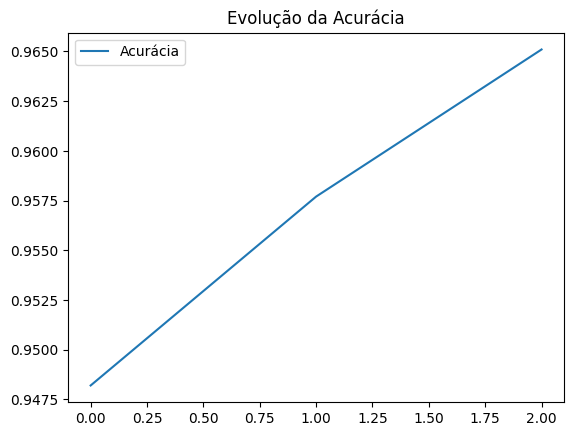

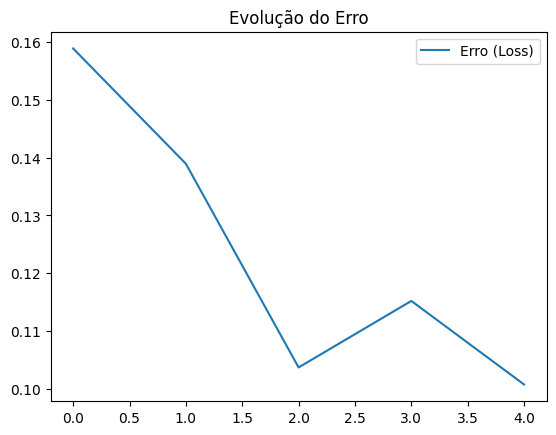

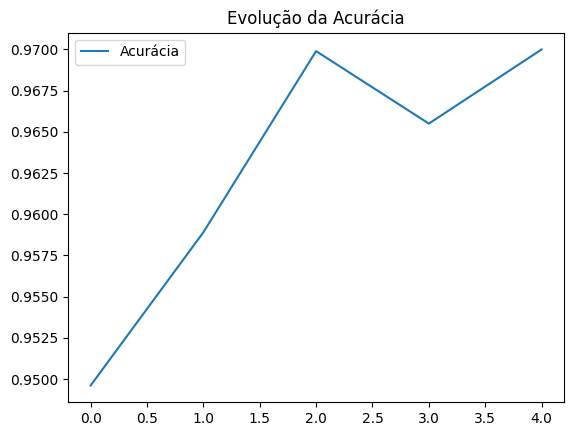

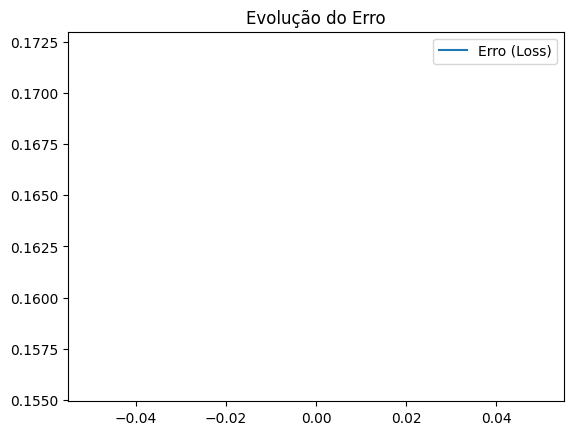

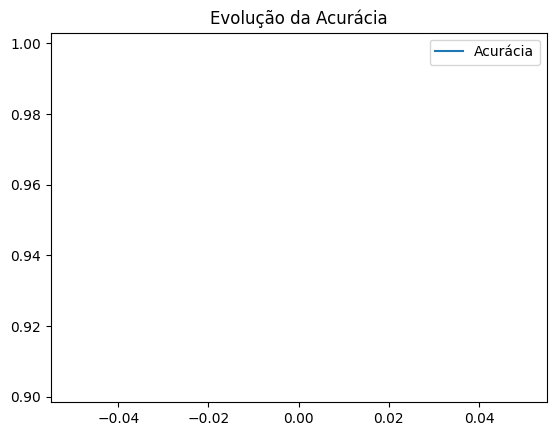

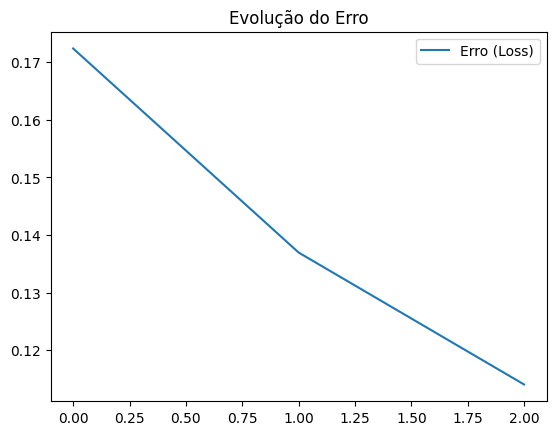

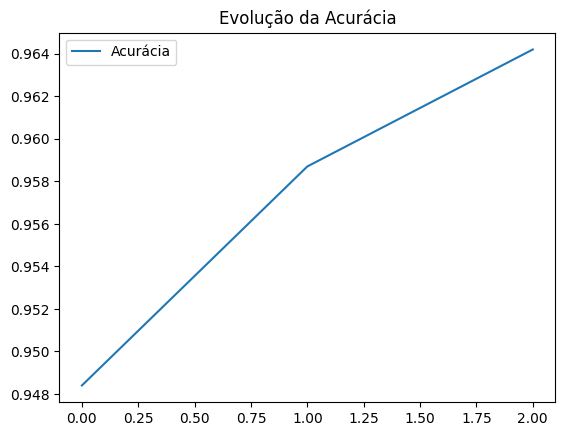

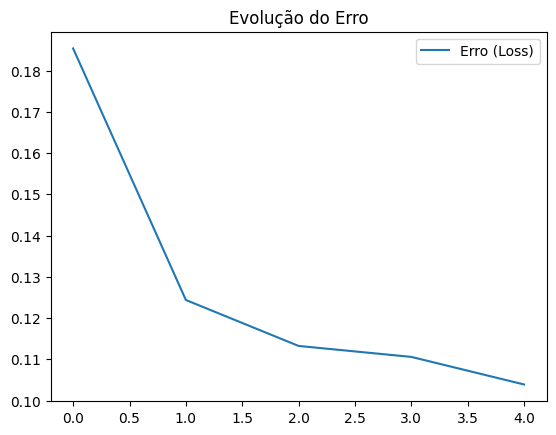

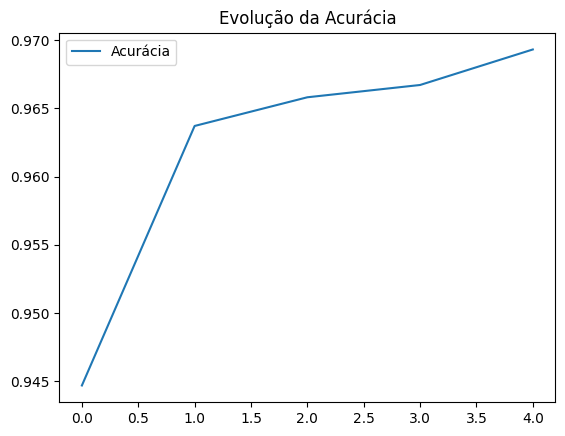

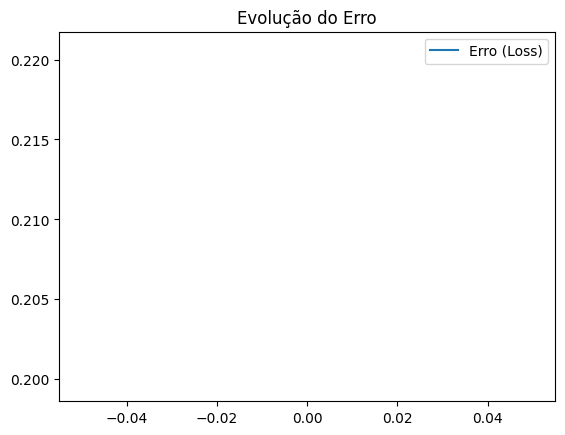

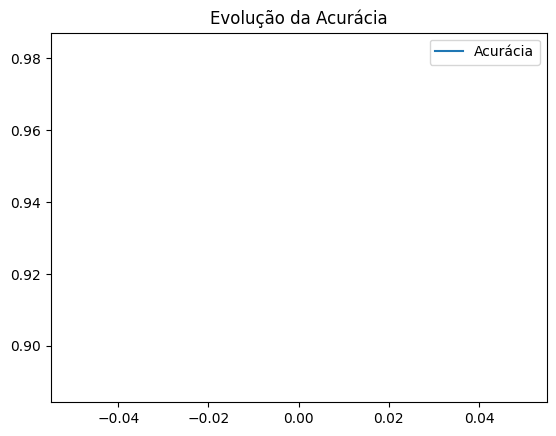

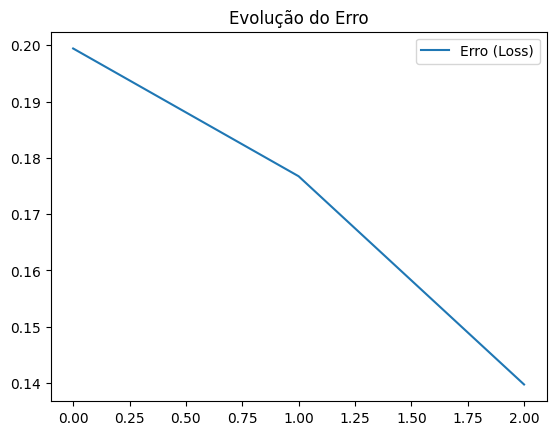

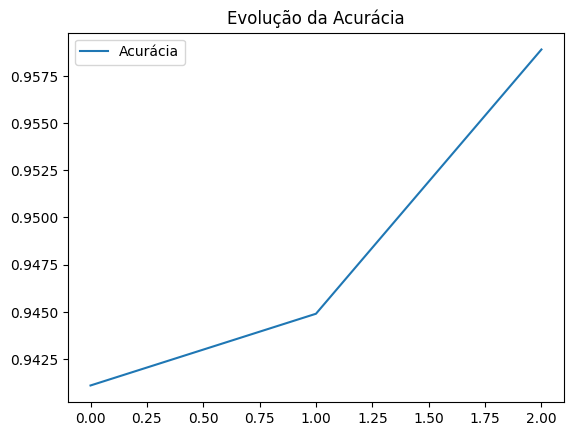

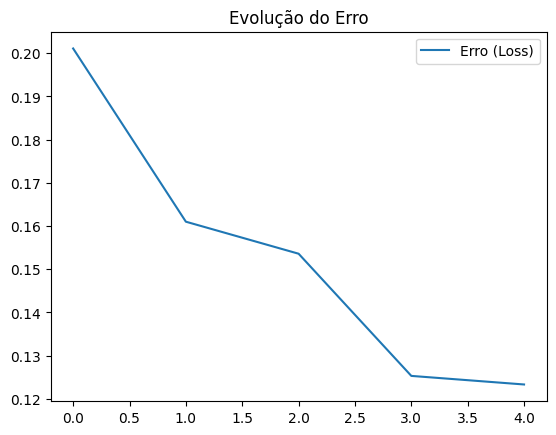

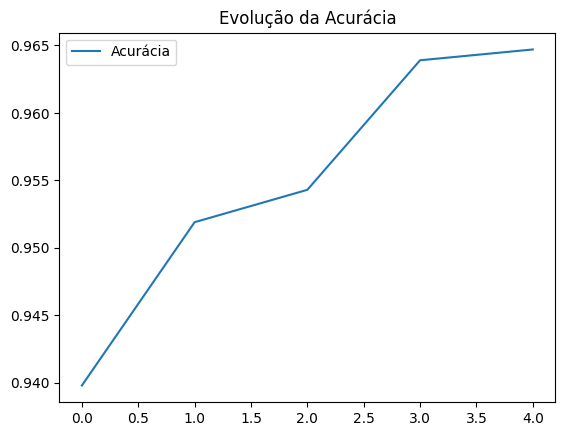

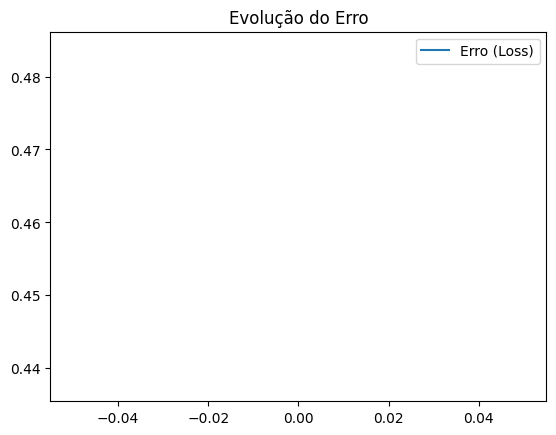

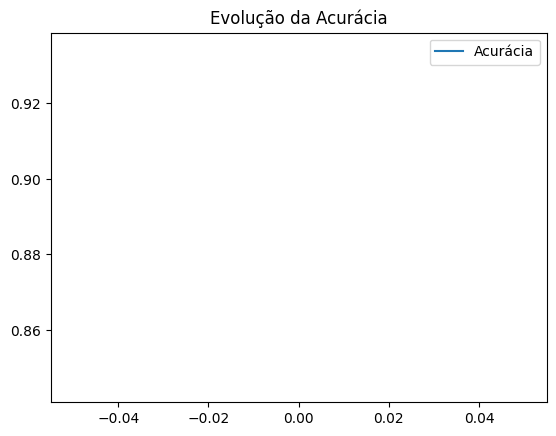

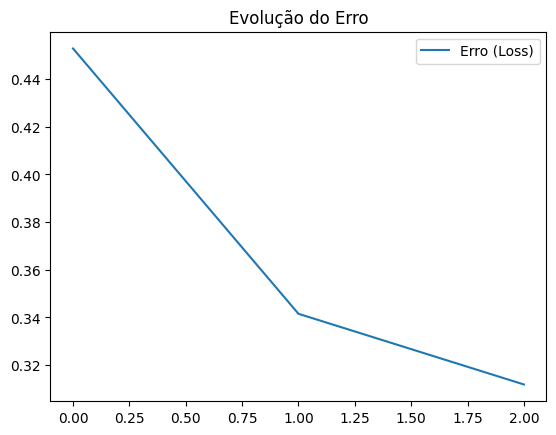

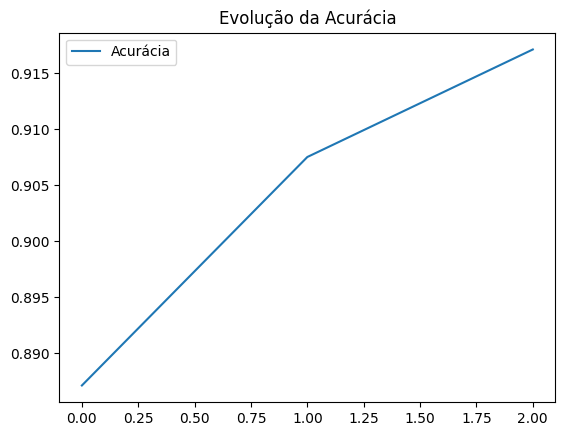

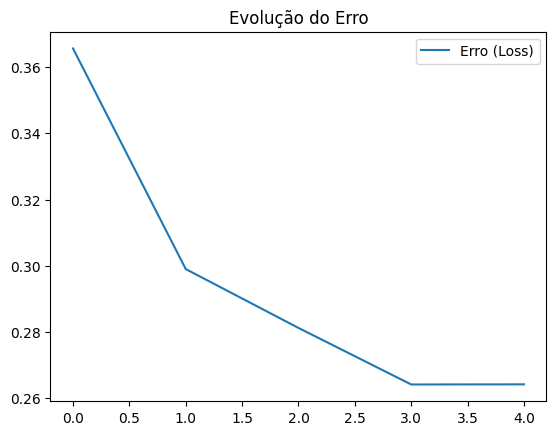

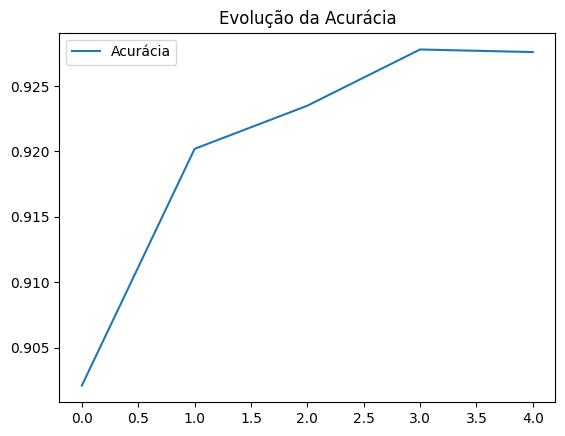

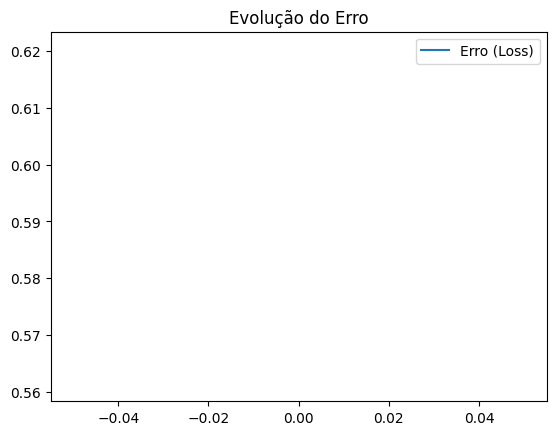

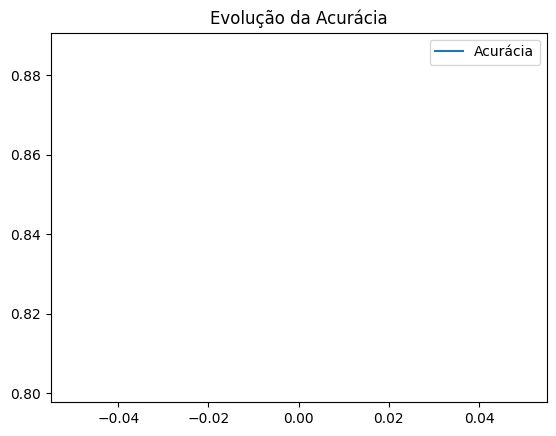

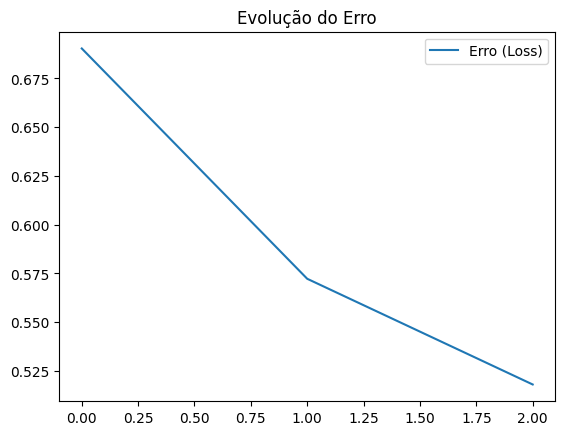

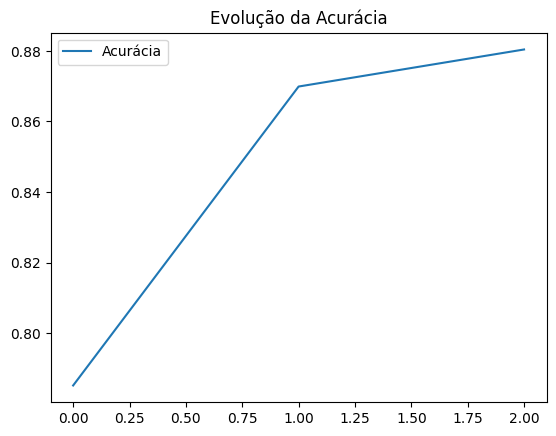

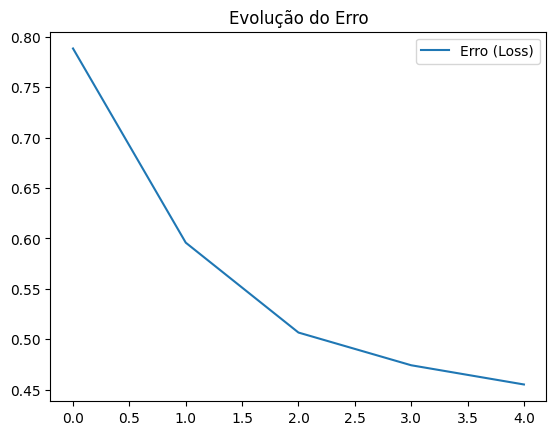

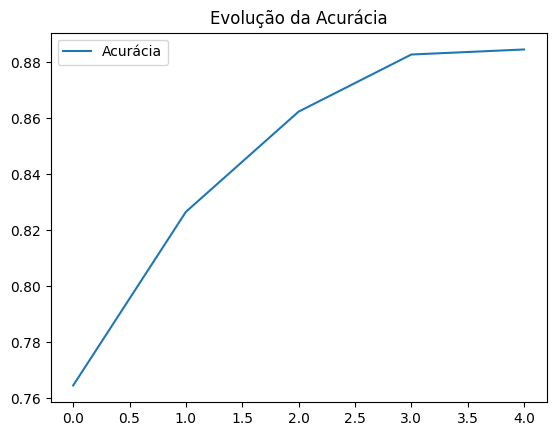

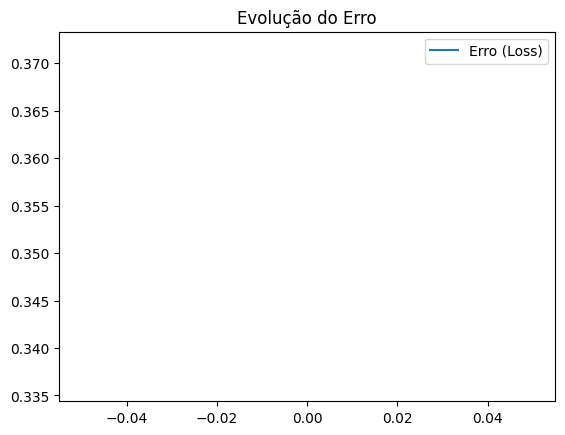

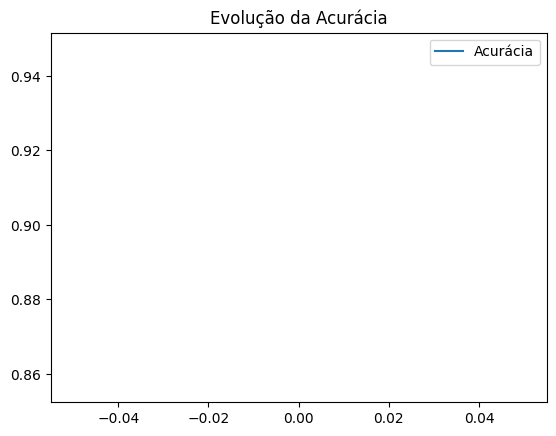

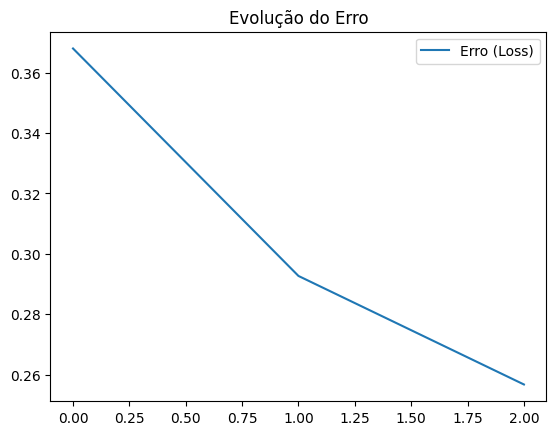

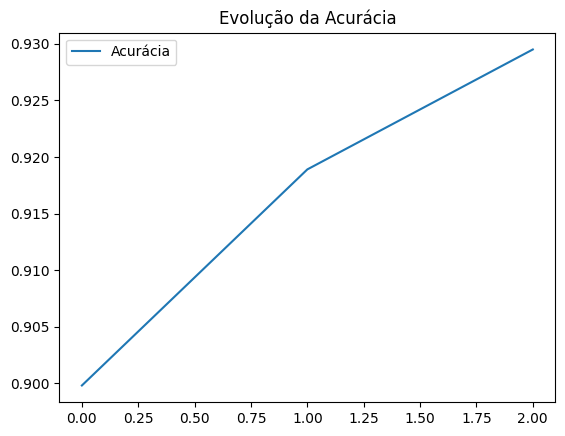

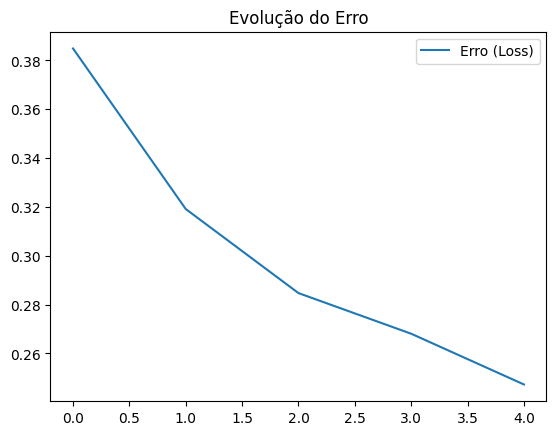

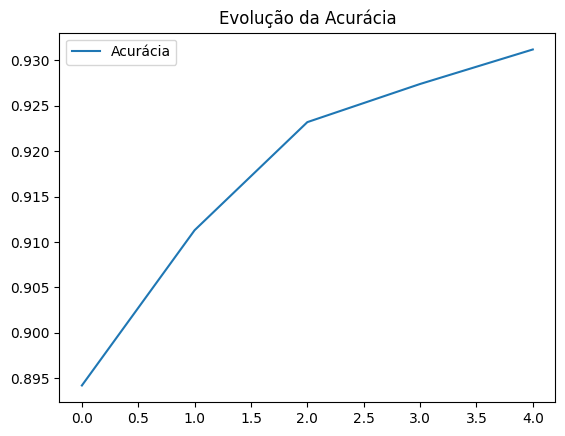

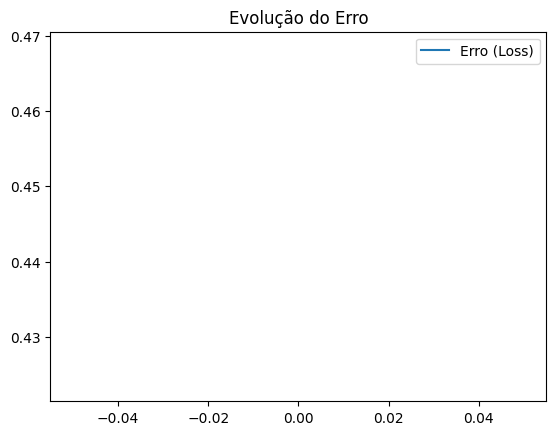

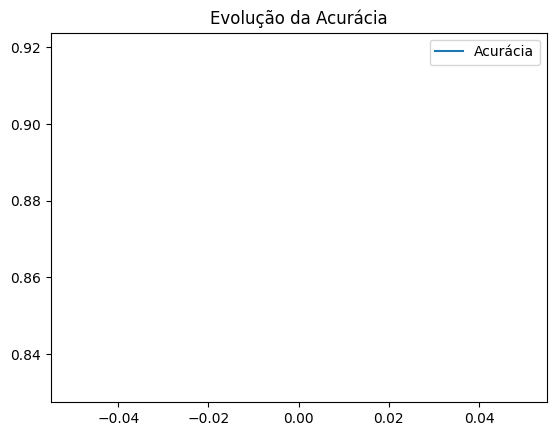

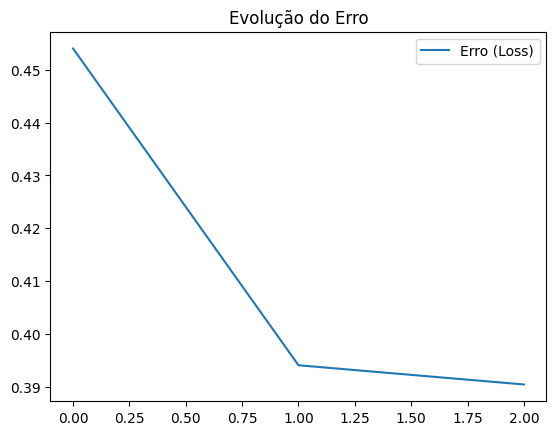

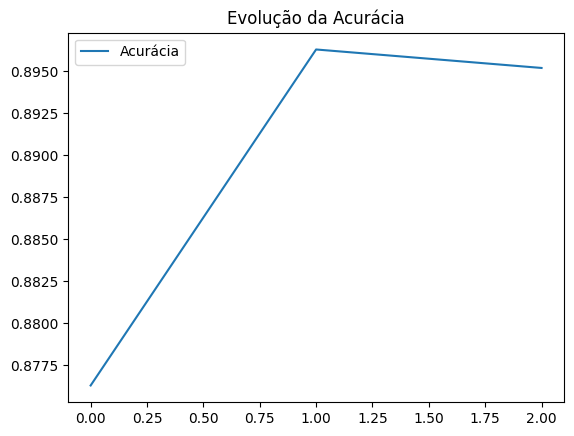

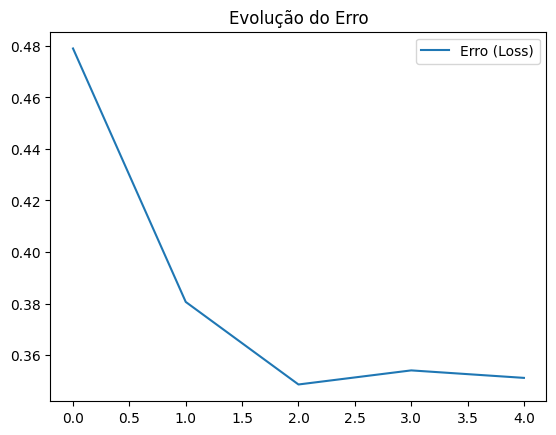

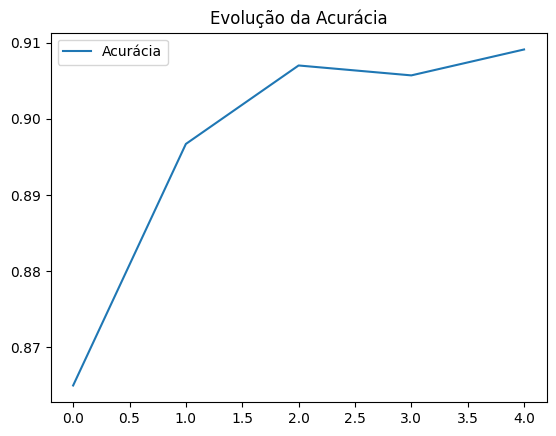

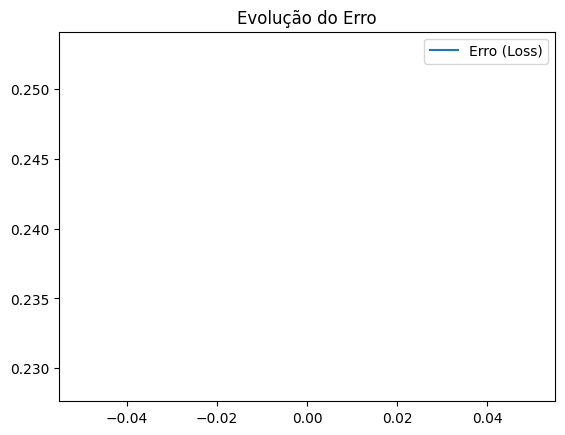

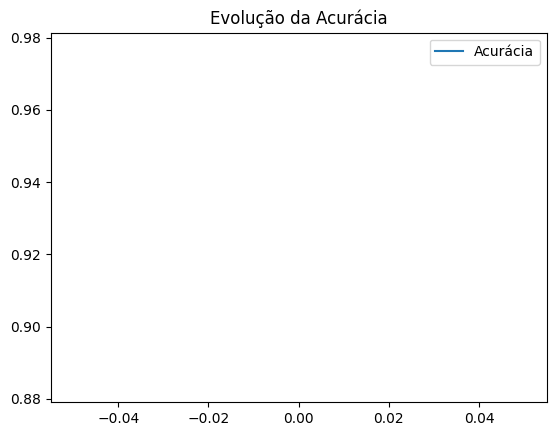

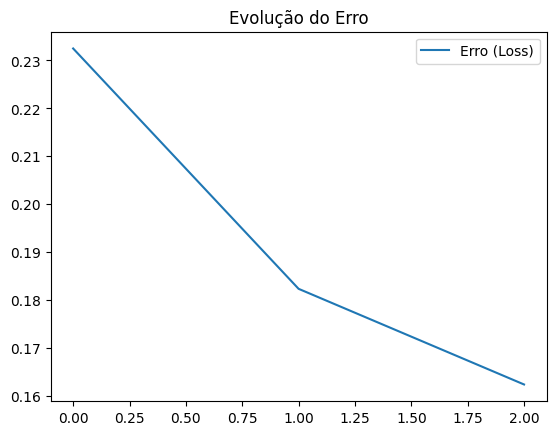

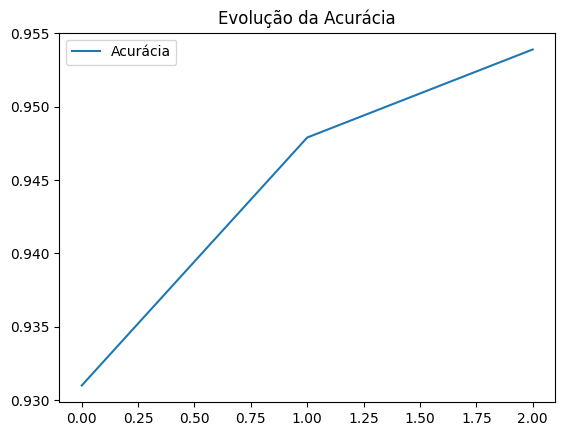

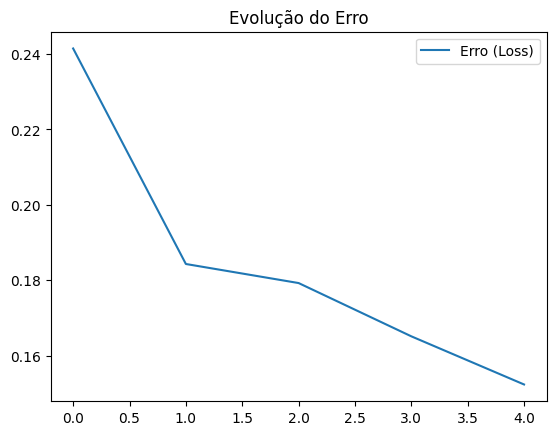

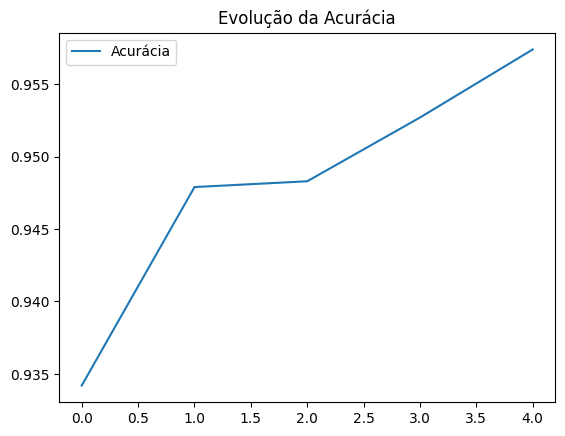

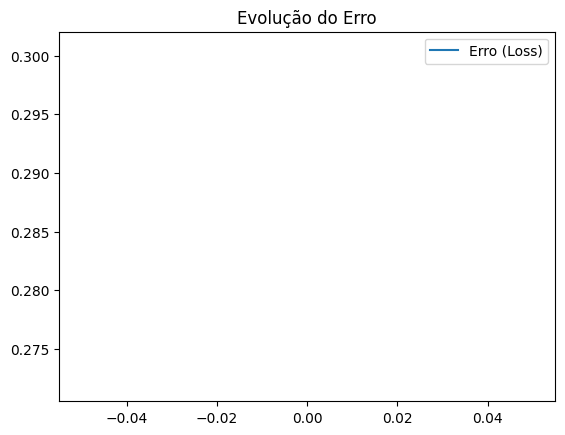

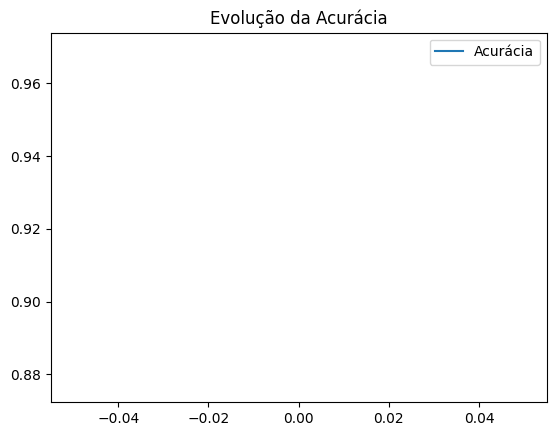

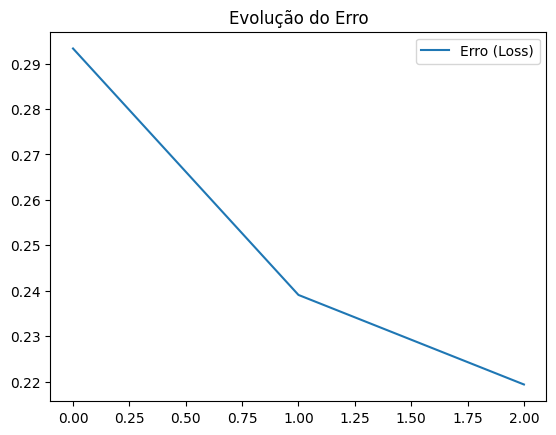

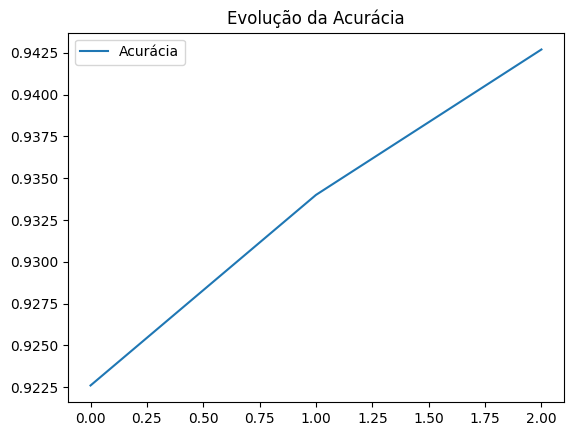

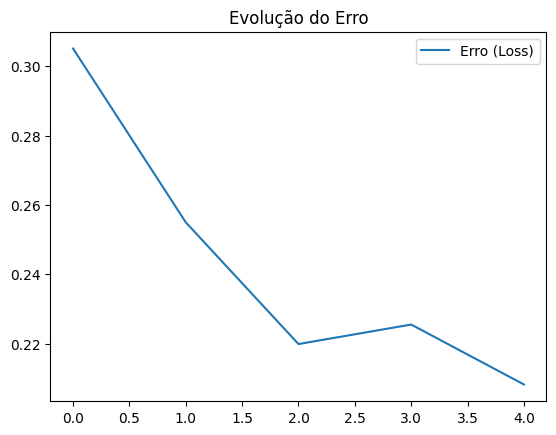

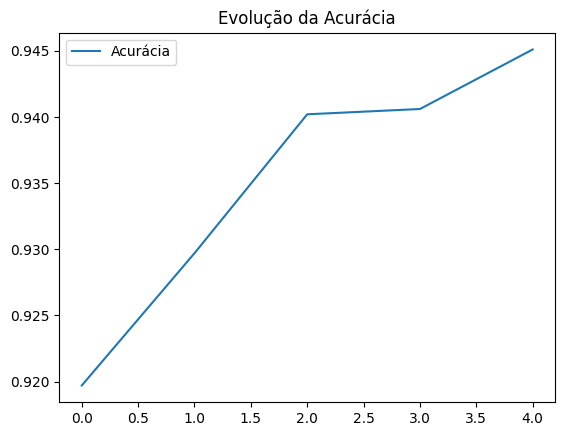

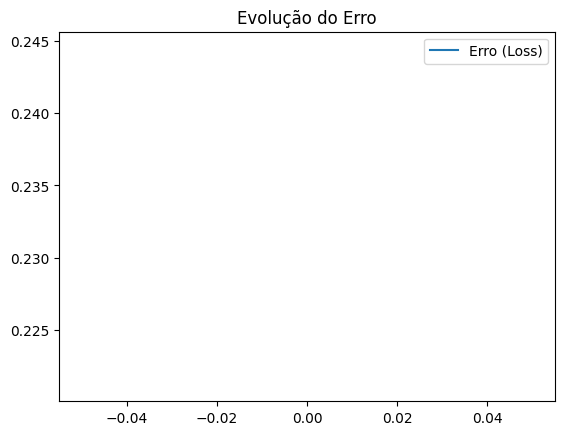

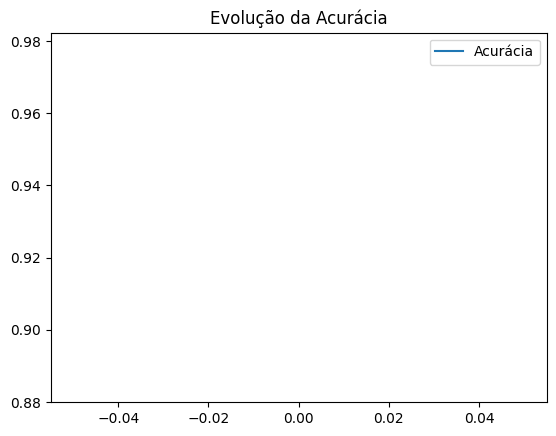

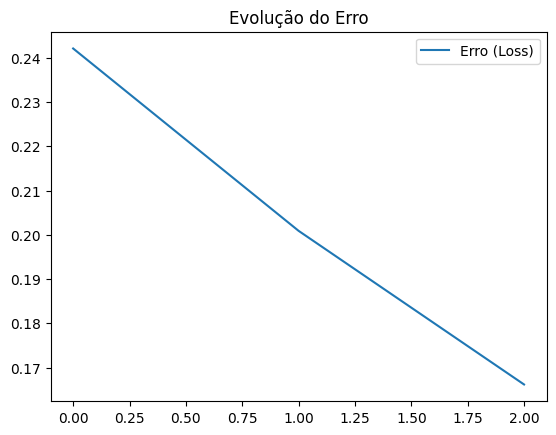

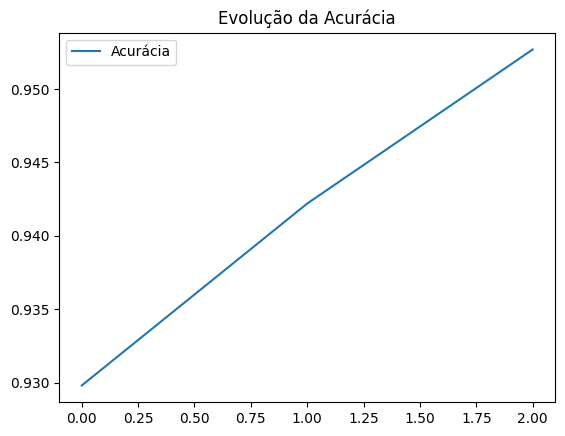

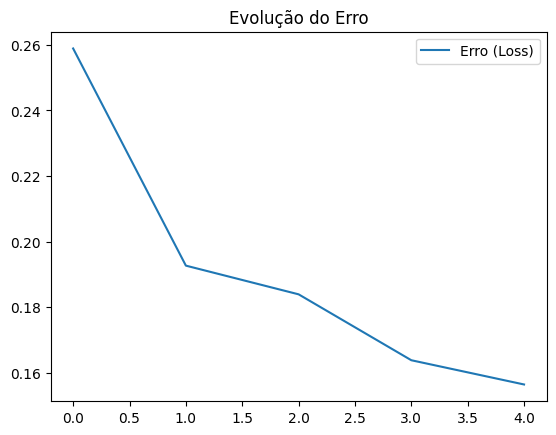

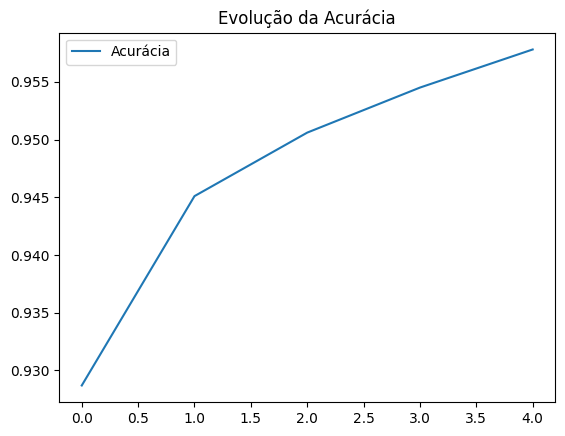

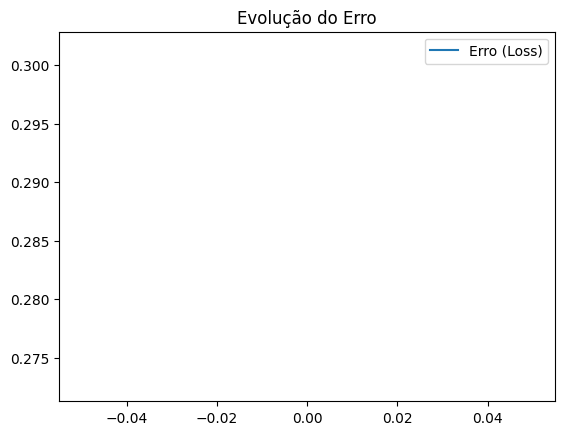

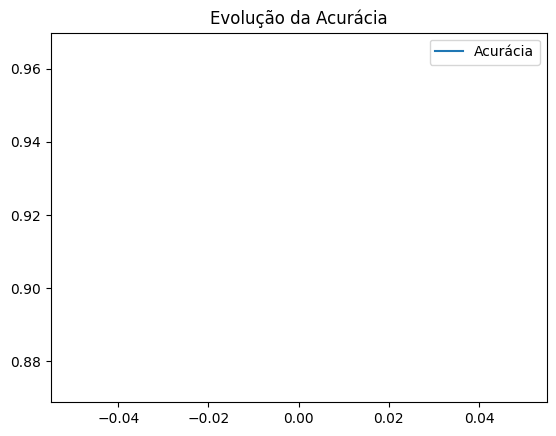

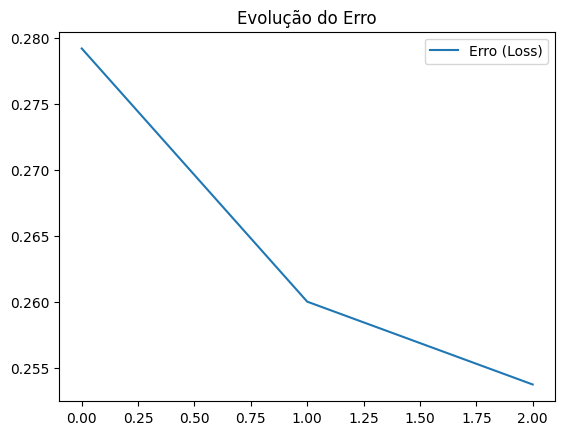

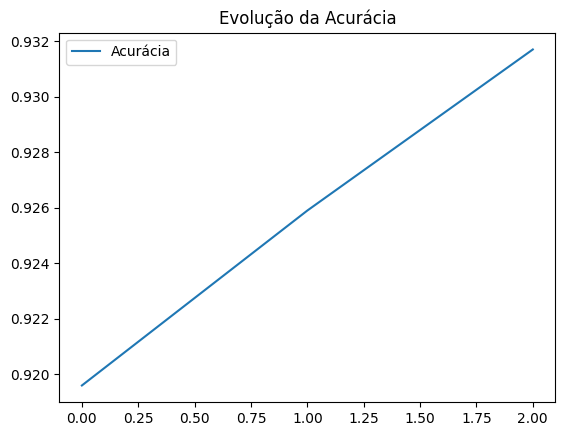

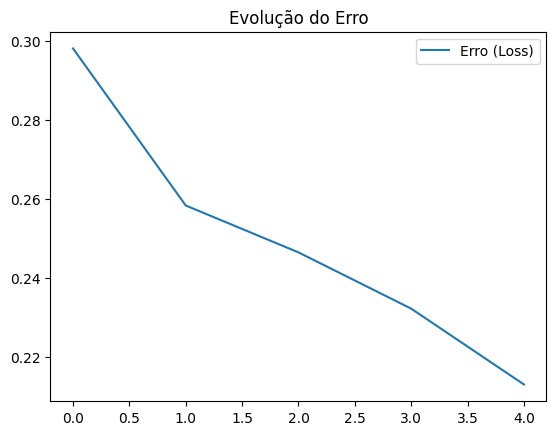

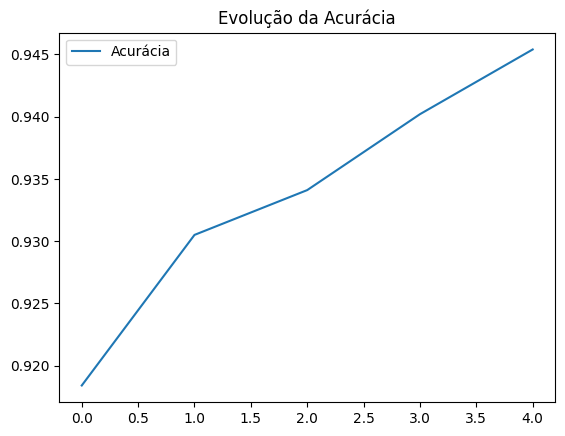

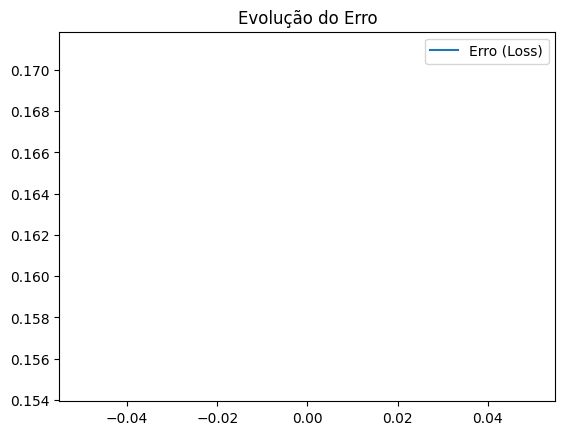

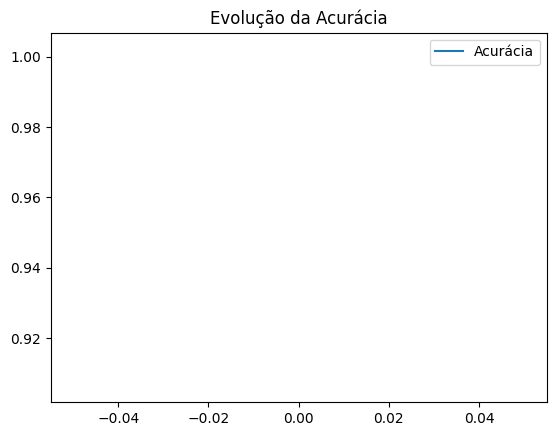

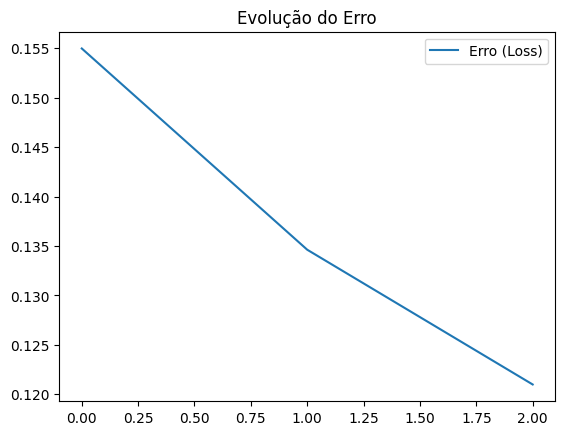

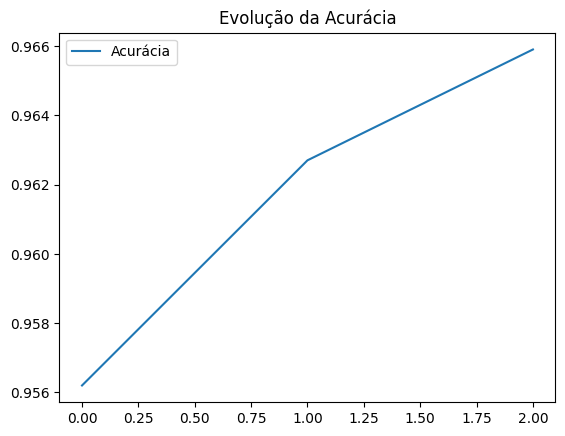

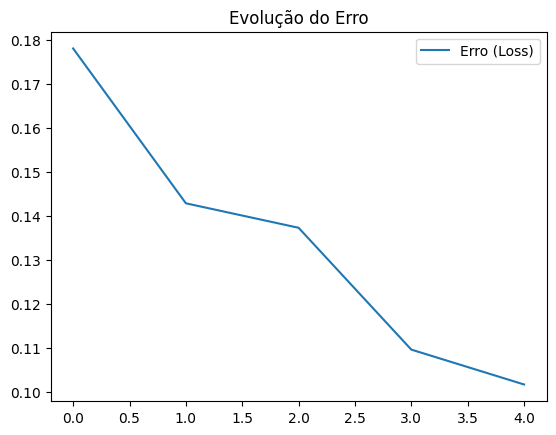

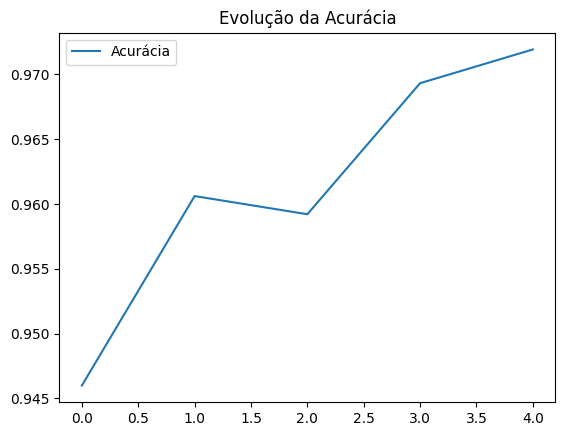

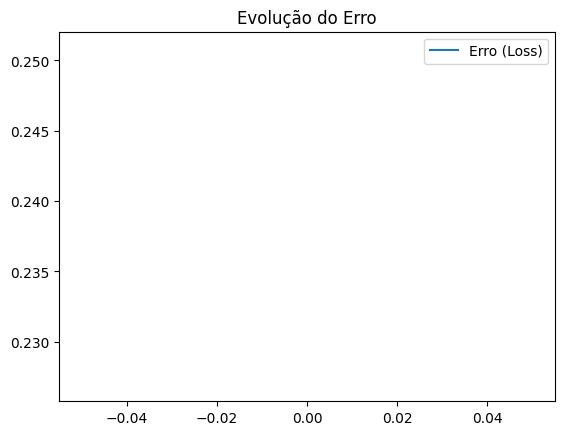

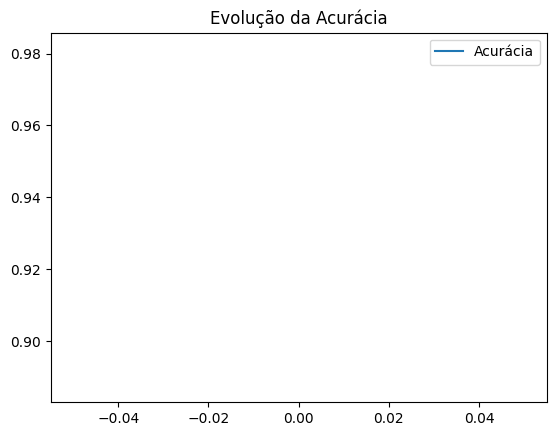

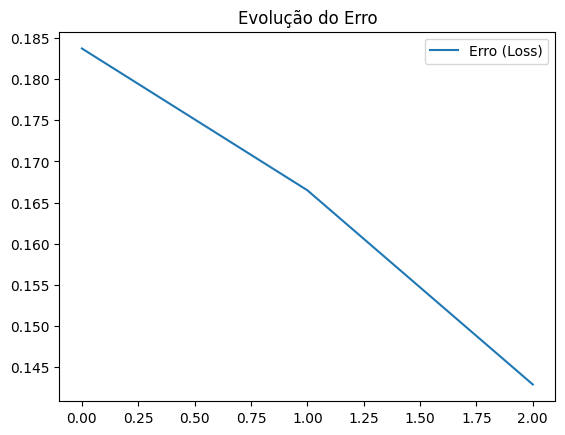

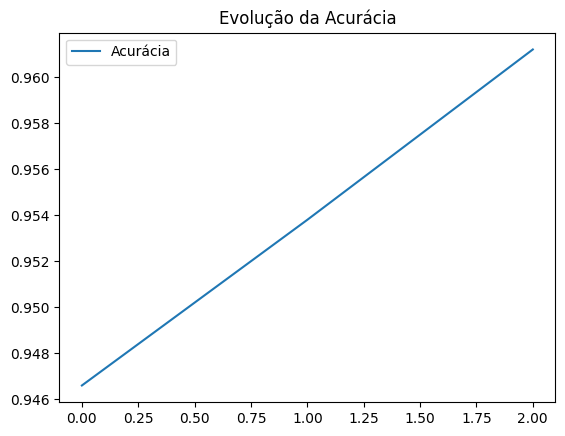

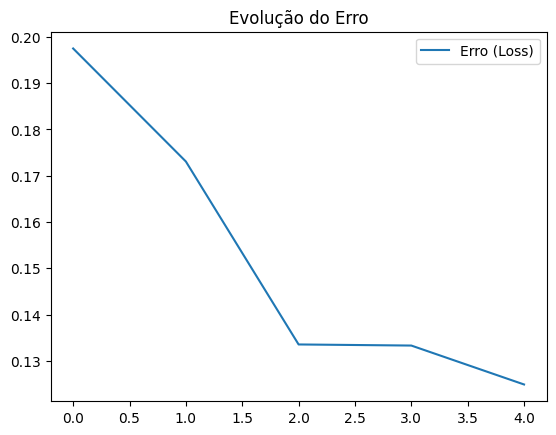

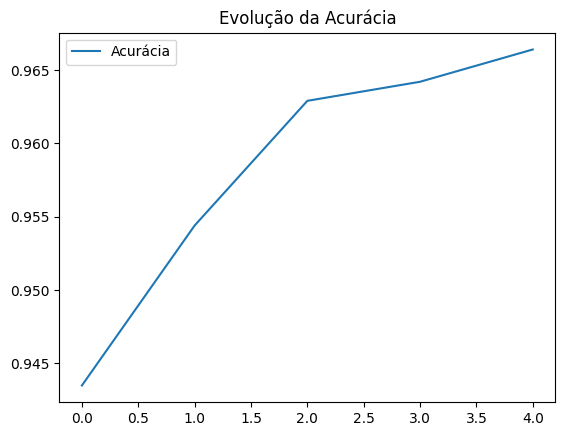

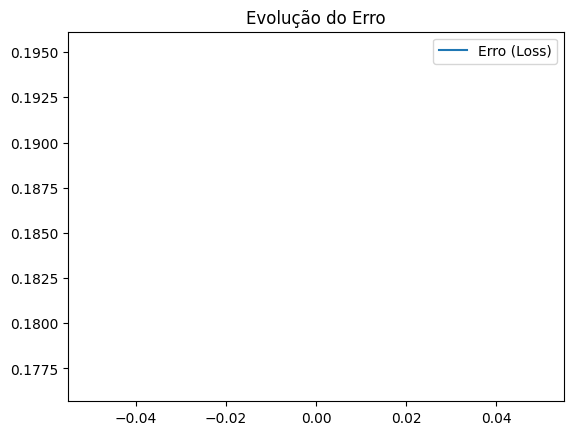

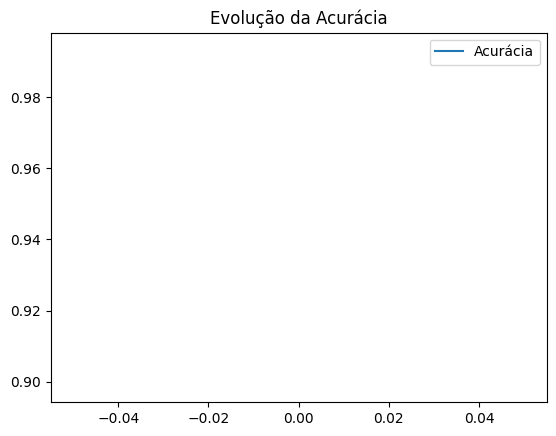

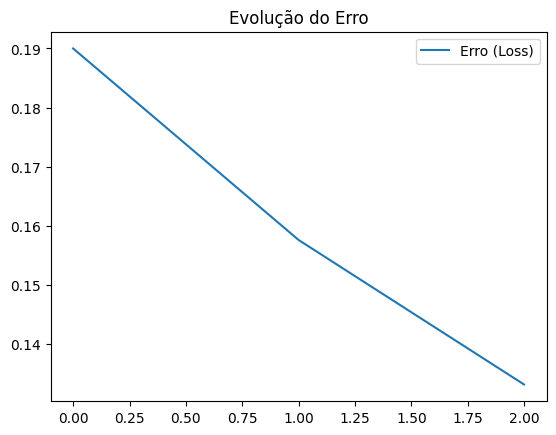

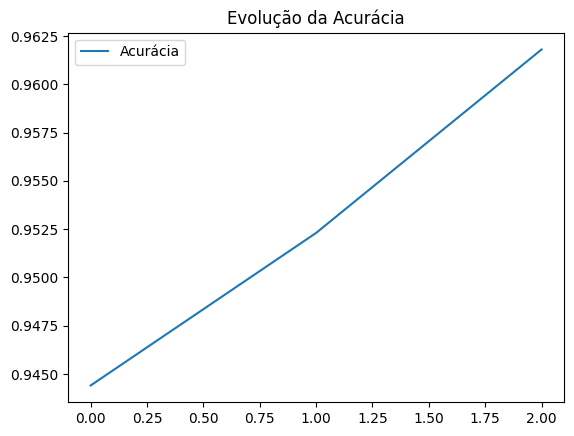

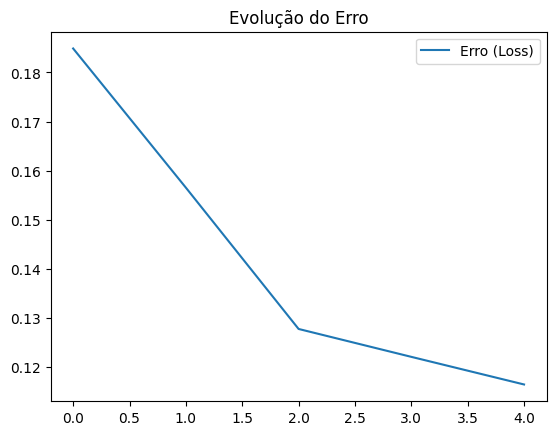

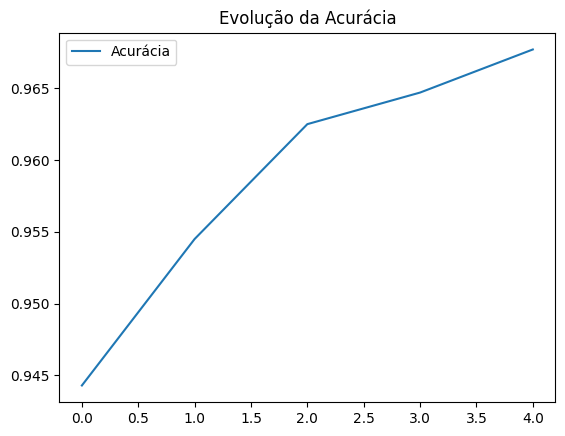

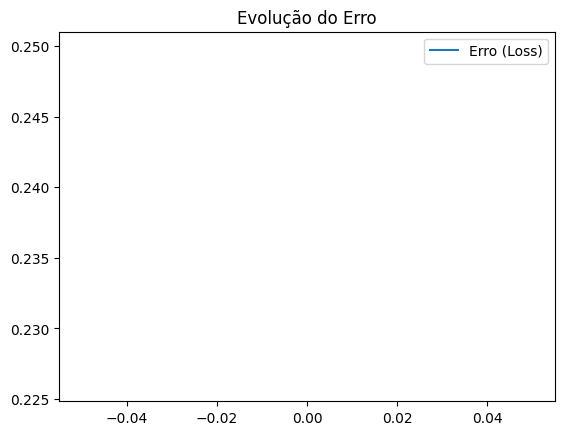

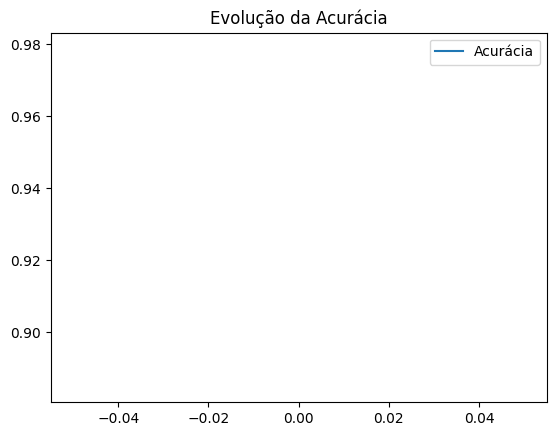

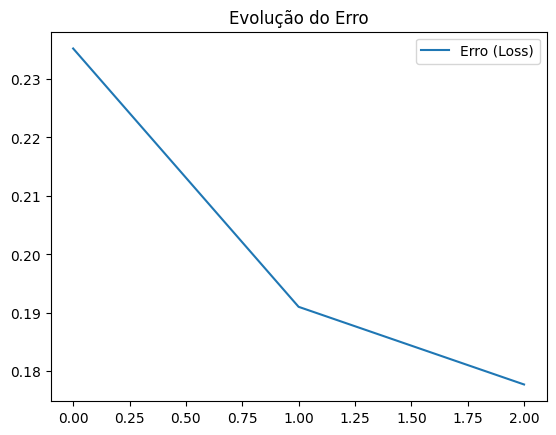

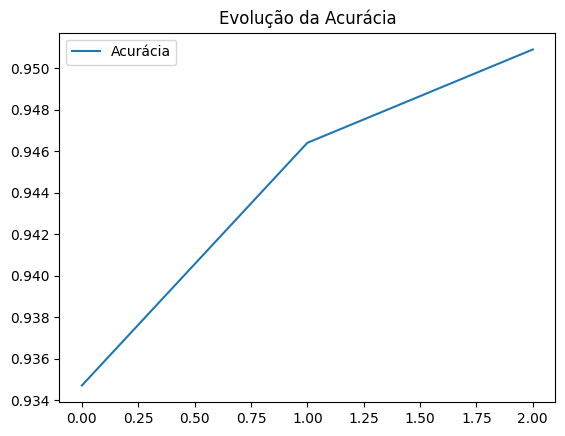

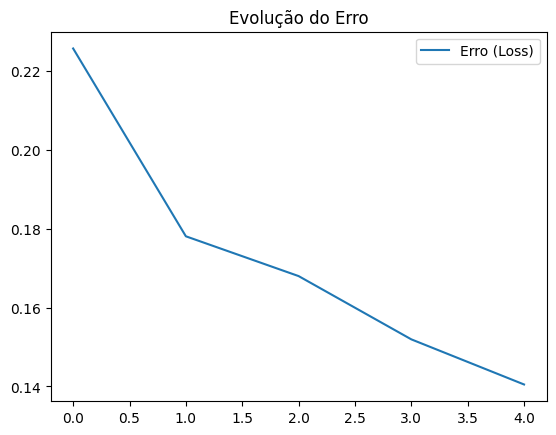

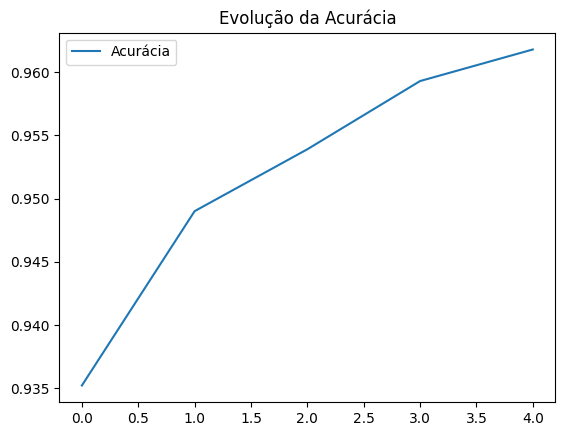

In [9]:
n_camadas_ocultas = [1, 2, 4]
n_units = [16, 32, 64]
activation = ['relu', 'tanh']
drop_out = [0.1, 0.2]
epochs = [1, 3, 5]

for camadas in n_camadas_ocultas:
    for unidades in n_units:
        for ativacao in activation:
            for drop in drop_out:
                for epocas in epochs:
                    treina_dl(camadas, unidades, ativacao, drop, epocas)